# 05 — Predictive Modeling

## Objective

The objective of this notebook is to train and compare supervised classification models for predicting Missed Delivery events.

The predictive dataset developed in the previous notebook contains only information available before the target delivery date.

To preserve the temporal nature of the problem, model evaluation is performed using a chronological train-test split rather than a random split.

The modelling workflow includes:

- temporal train-test separation;
- preprocessing fitted exclusively on training data;
- treatment of missing values;
- categorical encoding;
- numerical scaling when required;
- class-imbalance handling;
- baseline model comparison;
- model evaluation using metrics suitable for imbalanced classification.

The primary target is:

$$
y =
\begin{cases}
1 & \text{if a Missed Delivery occurs} \\
0 & \text{otherwise}
\end{cases}
$$

Because Missed Delivery represents approximately 8% of the observations, accuracy is not considered sufficient as the main performance metric. Precision, Recall, F1-score and PR-AUC will receive greater attention.

In [1]:
# Dependencies are managed from the repository requirements file.

In [2]:
# No runtime package installation is performed inside this notebook.

In [3]:
# ============================================================
# IMPORTS
# ============================================================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    average_precision_score,
    roc_auc_score
)

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)

In [4]:
# ============================================================
# LOAD FEATURE-ENGINEERED DATASET
# ============================================================

data_path = "../../data/processed/dataset_features.csv"

df = pd.read_csv(
    data_path,
    parse_dates=["Fecha"]
)

print("Dataset shape:", df.shape)
print(
    "Date range:",
    df["Fecha"].min(),
    "->",
    df["Fecha"].max()
)

print("\nTarget distribution:")
print(
    df["missed_delivery"]
    .value_counts()
)

print("\nTarget rate:")
print(
    f"{df['missed_delivery'].mean() * 100:.2f}%"
)

Dataset shape: (33971, 156)
Date range: 2025-01-02 00:00:00 -> 2026-08-25 00:00:00

Target distribution:
missed_delivery
0    31256
1     2715
Name: count, dtype: int64

Target rate:
7.99%


In [5]:
# ============================================================
# MONTHLY TARGET DISTRIBUTION
# ============================================================

monthly_distribution = (
    df
    .assign(
        year_month=df["Fecha"]
        .dt.to_period("M")
        .astype(str)
    )
    .groupby("year_month")
    .agg(
        rows=("missed_delivery", "size"),
        md=("missed_delivery", "sum"),
        md_rate=("missed_delivery", "mean")
    )
    .reset_index()
)

monthly_distribution["md_rate"] *= 100

display(monthly_distribution)

C:\Users\heresc\AppData\Local\Temp\ipykernel_22248\2417827242.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  .assign(


,year_month,rows,md,md_rate
0,2025-01,1835,351,19.128065
1,2025-02,1724,217,12.587007
2,2025-03,1833,154,8.401528
3,2025-04,1792,237,13.225446
4,2025-05,1591,197,12.382150
5,2025-06,1943,144,7.411220
6,2025-07,1700,171,10.058824
7,2025-08,822,74,9.002433
8,2025-09,1902,77,4.048370
9,2025-10,1969,83,4.215338


## Temporal Train-Test Split

A chronological holdout strategy is used to evaluate the predictive models.

Observations up to April 30, 2026 are assigned to model development, while observations from May 1, 2026 onward form the final temporal holdout.

This approach simulates the intended production setting, where historical information is used to predict future Missed Delivery events.

The holdout covers May to August 2026. It was inspected once during an earlier Logistic Regression baseline experiment, so it is treated as a comparative temporal holdout rather than as a strictly blind assessment. That historical result is retained and documented below rather than removed. All subsequent model comparison, feature selection, and threshold selection are restricted to the training and validation periods.

August 2026 is a partial month, ending on August 25, and is retained because it represents the most recent operational period available in the dataset.

In [6]:
# ============================================================
# TEMPORAL TRAIN-TEST SPLIT
# ============================================================

cutoff_date = pd.Timestamp("2026-05-01")

train_df = df[
    df["Fecha"] < cutoff_date
].copy()

test_df = df[
    df["Fecha"] >= cutoff_date
].copy()


print("TEMPORAL SPLIT")
print("-" * 50)

print(
    "Train:",
    train_df["Fecha"].min(),
    "->",
    train_df["Fecha"].max()
)

print(
    "Test:",
    test_df["Fecha"].min(),
    "->",
    test_df["Fecha"].max()
)

print("\nTRAIN")
print(
    f"Rows: {len(train_df):,}"
)
print(
    f"MD: {train_df['missed_delivery'].sum():,}"
)
print(
    f"MD rate: "
    f"{train_df['missed_delivery'].mean() * 100:.2f}%"
)

print("\nTEST")
print(
    f"Rows: {len(test_df):,}"
)
print(
    f"MD: {test_df['missed_delivery'].sum():,}"
)
print(
    f"MD rate: "
    f"{test_df['missed_delivery'].mean() * 100:.2f}%"
)

print(
    f"\nTest proportion: "
    f"{len(test_df) / len(df) * 100:.2f}%"
)

TEMPORAL SPLIT
--------------------------------------------------
Train: 2025-01-02 00:00:00 -> 2026-04-30 00:00:00
Test: 2026-05-04 00:00:00 -> 2026-08-25 00:00:00

TRAIN
Rows: 28,274
MD: 2,355
MD rate: 8.33%

TEST
Rows: 5,697
MD: 360
MD rate: 6.32%

Test proportion: 16.77%


### Temporal Split Results

The chronological split produces 28,274 training observations and 5,697 test observations.

The training period contains 2,355 Missed Delivery events, corresponding to an MD rate of 8.33%.

The temporal holdout contains 360 Missed Delivery events, with an MD rate of 6.32%.

The difference in target prevalence between the development and holdout periods is preserved rather than artificially corrected, since it reflects the temporal evolution of the operational process.

Because this period was inspected during the initial Logistic Regression baseline, it is not a strictly blind assessment. It remains temporally separated and useful as a comparative holdout, but the strongest unbiased evidence must come from validation, temporal backtesting, and future prospective data.

In [7]:
# ============================================================
# TRAIN / TEST MATRICES
# ============================================================

target_col = "missed_delivery"
date_col = "Fecha"

categorical_cols = [
    "Grupo_raiz",
    "customer",
    "uat",
    "destination"
]

feature_cols = [
    col
    for col in df.columns
    if col not in [
        target_col,
        date_col
    ]
]

numeric_cols = [
    col
    for col in feature_cols
    if col not in categorical_cols
]


X_train = train_df[feature_cols].copy()
y_train = train_df[target_col].copy()

X_test = test_df[feature_cols].copy()
y_test = test_df[target_col].copy()


print("FEATURE MATRICES")
print("-" * 50)

print("X_train:", X_train.shape)
print("X_test: ", X_test.shape)

print(
    f"\nNumeric features: "
    f"{len(numeric_cols)}"
)

print(
    f"Categorical features: "
    f"{len(categorical_cols)}"
)

print(
    f"Total predictors: "
    f"{len(feature_cols)}"
)

print("\nTarget train:")
print(y_train.value_counts())

print("\nTarget test:")
print(y_test.value_counts())

FEATURE MATRICES
--------------------------------------------------
X_train: (28274, 154)
X_test:  (5697, 154)

Numeric features: 150
Categorical features: 4
Total predictors: 154

Target train:
missed_delivery
0    25919
1     2355
Name: count, dtype: int64

Target test:
missed_delivery
0    5337
1     360
Name: count, dtype: int64


## Baseline Model — Logistic Regression

Logistic Regression is used as the first baseline classifier because it provides a simple and interpretable reference model.

Preprocessing is fitted exclusively on the training data.

Numerical variables are processed using:

- median imputation for missing values;
- standard scaling.

Categorical variables are processed using:

- most-frequent imputation;
- one-hot encoding with unknown-category handling.

Class imbalance is addressed using:

`class_weight="balanced"`

This increases the penalty associated with misclassifying the minority Missed Delivery class without artificially modifying the test distribution.

In [8]:
# ============================================================
# LOGISTIC REGRESSION BASELINE PIPELINE
# ============================================================

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

from sklearn.linear_model import LogisticRegression


# ------------------------------------------------------------
# NUMERICAL PREPROCESSING
# ------------------------------------------------------------

numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)


# ------------------------------------------------------------
# CATEGORICAL PREPROCESSING
# ------------------------------------------------------------

categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)


# ------------------------------------------------------------
# COLUMN TRANSFORMER
# ------------------------------------------------------------

preprocessor_lr = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_pipeline,
            numeric_cols
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_cols
        )
    ]
)


# ------------------------------------------------------------
# LOGISTIC REGRESSION
# ------------------------------------------------------------

logistic_model = LogisticRegression(
    class_weight="balanced",
    max_iter=2000,
    random_state=42
)


# ------------------------------------------------------------
# COMPLETE PIPELINE
# ------------------------------------------------------------

logistic_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor_lr
        ),
        (
            "model",
            logistic_model
        )
    ]
)


# ============================================================
# TRAIN
# ============================================================

logistic_pipeline.fit(
    X_train,
    y_train
)

print(
    "Logistic Regression training completed."
)

Logistic Regression training completed.


## Baseline Evaluation

The Logistic Regression model is first evaluated using the default classification threshold of 0.5.

Because the target is imbalanced, the evaluation focuses on:

- Precision;
- Recall;
- F1-score;
- PR-AUC;
- ROC-AUC;
- confusion matrix.

The default threshold is retained at this stage to establish an unbiased baseline before exploring threshold optimization.

In [9]:
# ============================================================
# LOGISTIC REGRESSION BASELINE EVALUATION
# ============================================================

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    average_precision_score,
    roc_auc_score
)


# Predicted probabilities
y_prob_lr = logistic_pipeline.predict_proba(
    X_test
)[:, 1]


# Default threshold = 0.5
y_pred_lr = (
    y_prob_lr >= 0.5
).astype(int)


# ============================================================
# METRICS
# ============================================================

precision_lr = precision_score(
    y_test,
    y_pred_lr
)

recall_lr = recall_score(
    y_test,
    y_pred_lr
)

f1_lr = f1_score(
    y_test,
    y_pred_lr
)

pr_auc_lr = average_precision_score(
    y_test,
    y_prob_lr
)

roc_auc_lr = roc_auc_score(
    y_test,
    y_prob_lr
)


print("LOGISTIC REGRESSION — TEST RESULTS")
print("-" * 50)

print(
    f"Precision: {precision_lr:.4f}"
)

print(
    f"Recall:    {recall_lr:.4f}"
)

print(
    f"F1-score:  {f1_lr:.4f}"
)

print(
    f"PR-AUC:    {pr_auc_lr:.4f}"
)

print(
    f"ROC-AUC:   {roc_auc_lr:.4f}"
)


print("\nCONFUSION MATRIX")
print("-" * 50)

cm_lr = confusion_matrix(
    y_test,
    y_pred_lr
)

print(cm_lr)


print("\nCLASSIFICATION REPORT")
print("-" * 50)

print(
    classification_report(
        y_test,
        y_pred_lr,
        digits=4
    )
)

LOGISTIC REGRESSION — TEST RESULTS
--------------------------------------------------
Precision: 0.3317
Recall:    0.7389
F1-score:  0.4578
PR-AUC:    0.3374
ROC-AUC:   0.8910

CONFUSION MATRIX
--------------------------------------------------
[[4801  536]
 [  94  266]]

CLASSIFICATION REPORT
--------------------------------------------------
              precision    recall  f1-score   support

           0     0.9808    0.8996    0.9384      5337
           1     0.3317    0.7389    0.4578       360

    accuracy                         0.8894      5697
   macro avg     0.6562    0.8192    0.6981      5697
weighted avg     0.9398    0.8894    0.9081      5697



### Logistic Regression Baseline Results

The baseline Logistic Regression model demonstrates substantial predictive discrimination on the May-August temporal holdout.

Using the default 0.5 classification threshold, the model identifies 266 of the 360 Missed Delivery events, corresponding to a recall of 73.89%.

Precision is 33.17%, indicating that approximately one third of the generated MD alerts correspond to actual Missed Delivery events.

The model achieves an F1-score of 0.4578, a PR-AUC of 0.3374, and a ROC-AUC of 0.8910.

Given a Missed Delivery prevalence of only 6.32% in the temporal holdout, the PR-AUC is substantially higher than the approximate no-skill baseline of 0.0632.

The results indicate that historical operational and temporal features contain meaningful predictive information. However, this early inspection means that the period cannot serve as a strictly blind assessment. These metrics are retained transparently as an exploratory baseline and are not used for subsequent model, feature, or threshold selection.

In [10]:
# ============================================================
# TEMPORAL TRAIN / VALIDATION / TEST SPLIT
# ============================================================

validation_cutoff = pd.Timestamp("2026-02-01")
test_cutoff = pd.Timestamp("2026-05-01")


train_final_df = df[
    df["Fecha"] < validation_cutoff
].copy()

validation_df = df[
    (df["Fecha"] >= validation_cutoff)
    & (df["Fecha"] < test_cutoff)
].copy()

test_final_df = df[
    df["Fecha"] >= test_cutoff
].copy()


split_summary = pd.DataFrame({
    "split": [
        "Train",
        "Validation",
        "Test"
    ],

    "rows": [
        len(train_final_df),
        len(validation_df),
        len(test_final_df)
    ],

    "md": [
        train_final_df["missed_delivery"].sum(),
        validation_df["missed_delivery"].sum(),
        test_final_df["missed_delivery"].sum()
    ],

    "md_rate": [
        train_final_df["missed_delivery"].mean() * 100,
        validation_df["missed_delivery"].mean() * 100,
        test_final_df["missed_delivery"].mean() * 100
    ],

    "start_date": [
        train_final_df["Fecha"].min(),
        validation_df["Fecha"].min(),
        test_final_df["Fecha"].min()
    ],

    "end_date": [
        train_final_df["Fecha"].max(),
        validation_df["Fecha"].max(),
        test_final_df["Fecha"].max()
    ]
})

display(split_summary)

,split,rows,md,md_rate,start_date,end_date
0,Train,22342,2036,9.112882,2025-01-02,2026-01-31
1,Validation,5932,319,5.377613,2026-02-02,2026-04-30
2,Test,5697,360,6.319115,2026-05-04,2026-08-25


### Final Temporal Data Partition

The dataset is divided chronologically into three non-overlapping periods:

- Training: January 2025 to January 2026;
- Validation: February 2026 to April 2026;
- Test: May 2026 to August 2026.

The validation set contains 319 Missed Delivery events, providing a sufficiently large minority-class sample for model comparison and classification-threshold selection.

The target prevalence varies across periods, decreasing from 9.11% in training to 5.38% in validation and 6.32% in testing.

This temporal variation is intentionally preserved because it reflects changes in the real operational process and provides a more realistic assessment of model generalisation.

In [11]:
# ============================================================
# FINAL TRAIN / VALIDATION MATRICES
# ============================================================

X_train_final = train_final_df[
    feature_cols
].copy()

y_train_final = train_final_df[
    target_col
].copy()

X_val = validation_df[
    feature_cols
].copy()

y_val = validation_df[
    target_col
].copy()


print("Train:", X_train_final.shape)
print("Validation:", X_val.shape)

print(
    f"\nTrain MD rate: "
    f"{y_train_final.mean() * 100:.2f}%"
)

print(
    f"Validation MD rate: "
    f"{y_val.mean() * 100:.2f}%"
)

Train: (22342, 154)
Validation: (5932, 154)

Train MD rate: 9.11%
Validation MD rate: 5.38%


In [12]:
# ============================================================
# RETRAIN LOGISTIC REGRESSION
# USING TRAIN PERIOD ONLY
# ============================================================

logistic_pipeline.fit(
    X_train_final,
    y_train_final
)


# Validation probabilities
y_prob_lr_val = (
    logistic_pipeline
    .predict_proba(X_val)[:, 1]
)


# Default threshold
y_pred_lr_val = (
    y_prob_lr_val >= 0.5
).astype(int)


# ============================================================
# VALIDATION METRICS
# ============================================================

precision_lr_val = precision_score(
    y_val,
    y_pred_lr_val
)

recall_lr_val = recall_score(
    y_val,
    y_pred_lr_val
)

f1_lr_val = f1_score(
    y_val,
    y_pred_lr_val
)

pr_auc_lr_val = average_precision_score(
    y_val,
    y_prob_lr_val
)

roc_auc_lr_val = roc_auc_score(
    y_val,
    y_prob_lr_val
)


print(
    "LOGISTIC REGRESSION — VALIDATION RESULTS"
)

print("-" * 50)

print(
    f"Precision: {precision_lr_val:.4f}"
)

print(
    f"Recall:    {recall_lr_val:.4f}"
)

print(
    f"F1-score:  {f1_lr_val:.4f}"
)

print(
    f"PR-AUC:    {pr_auc_lr_val:.4f}"
)

print(
    f"ROC-AUC:   {roc_auc_lr_val:.4f}"
)

print("\nConfusion matrix:")

print(
    confusion_matrix(
        y_val,
        y_pred_lr_val
    )
)

LOGISTIC REGRESSION — VALIDATION RESULTS
--------------------------------------------------
Precision: 0.1900
Recall:    0.7116
F1-score:  0.2999
PR-AUC:    0.2281
ROC-AUC:   0.8179

Confusion matrix:
[[4645  968]
 [  92  227]]


### Logistic Regression Validation Performance

When evaluated on the independent temporal validation period, Logistic Regression achieves a recall of 71.16%, identifying 227 of the 319 Missed Delivery events.

Precision is 19.00%, indicating that the high sensitivity is obtained at the cost of a relatively large number of false-positive alerts.

The model achieves an F1-score of 0.2999, a PR-AUC of 0.2281, and a ROC-AUC of 0.8179.

Although performance is lower than that observed in the initial train-test experiment, the validation period represents a stricter temporal evaluation and contains a lower Missed Delivery prevalence of 5.38%.

The PR-AUC remains substantially above the approximate no-skill baseline associated with the validation prevalence, indicating that the historical features retain meaningful predictive information.

In [13]:
# ============================================================
# CLASSIFICATION THRESHOLD ANALYSIS
# VALIDATION SET ONLY
# ============================================================

thresholds = np.arange(
    0.10,
    0.91,
    0.05
)

threshold_results = []

for threshold in thresholds:

    y_pred_threshold = (
        y_prob_lr_val >= threshold
    ).astype(int)

    precision = precision_score(
        y_val,
        y_pred_threshold,
        zero_division=0
    )

    recall = recall_score(
        y_val,
        y_pred_threshold,
        zero_division=0
    )

    f1 = f1_score(
        y_val,
        y_pred_threshold,
        zero_division=0
    )

    tn, fp, fn, tp = confusion_matrix(
        y_val,
        y_pred_threshold
    ).ravel()

    threshold_results.append({
        "threshold": threshold,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "TP": tp,
        "FP": fp,
        "FN": fn,
        "TN": tn
    })


threshold_results = pd.DataFrame(
    threshold_results
)

display(
    threshold_results.round(4)
)

,threshold,precision,recall,f1,TP,FP,FN,TN
0,0.10,0.0636,0.9687,0.1193,309,4551,10,1062
1,0.15,0.0679,0.9342,0.1267,298,4088,21,1525
2,0.20,0.0767,0.9154,0.1416,292,3514,27,2099
3,0.25,0.0892,0.8840,0.1621,282,2879,37,2734
4,0.30,0.1009,0.8527,0.1805,272,2423,47,3190
5,0.35,0.1154,0.8213,0.2023,262,2009,57,3604
6,0.40,0.1334,0.7806,0.2279,249,1617,70,3996
7,0.45,0.1623,0.7492,0.2667,239,1234,80,4379
8,0.50,0.1900,0.7116,0.2999,227,968,92,4645
9,0.55,0.2088,0.6677,0.3181,213,807,106,4806


In [14]:
best_f1_row = (
    threshold_results
    .loc[
        threshold_results["f1"].idxmax()
    ]
)

print("BEST VALIDATION THRESHOLD BY F1")
print("-" * 50)

print(best_f1_row)

BEST VALIDATION THRESHOLD BY F1
--------------------------------------------------
threshold       0.700000
precision       0.254135
recall          0.529781
f1              0.343496
TP            169.000000
FP            496.000000
FN            150.000000
TN           5117.000000
Name: 12, dtype: float64


### Classification Threshold Analysis

The default classification threshold of 0.5 is not necessarily optimal for an imbalanced operational classification problem.

Threshold selection was therefore performed exclusively on the temporal validation set.

The highest validation F1-score was obtained at a threshold of 0.70.

At this threshold, Logistic Regression achieved:

- Precision: 25.41%;
- Recall: 52.98%;
- F1-score: 0.3435.

Increasing the threshold from 0.50 to 0.70 substantially reduces false-positive alerts, but also decreases the proportion of Missed Delivery events detected.

Therefore, threshold selection represents an operational trade-off between alert volume and missed-risk detection rather than a purely statistical decision.

## Random Forest

Random Forest is evaluated as a nonlinear tree-based alternative to Logistic Regression.

Unlike Logistic Regression, tree-based models do not require numerical standardisation and can capture nonlinear relationships and interactions between historical operational variables.

The same temporal training and validation periods are maintained to ensure a fair comparison.

Class imbalance is again addressed using balanced class weights.

In [15]:
# ============================================================
# RANDOM FOREST PIPELINE
# ============================================================

from sklearn.ensemble import RandomForestClassifier


# ------------------------------------------------------------
# NUMERICAL PREPROCESSING
# ------------------------------------------------------------

numeric_pipeline_rf = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        )
    ]
)


# ------------------------------------------------------------
# CATEGORICAL PREPROCESSING
# ------------------------------------------------------------

categorical_pipeline_rf = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)


# ------------------------------------------------------------
# PREPROCESSOR
# ------------------------------------------------------------

preprocessor_rf = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_pipeline_rf,
            numeric_cols
        ),
        (
            "categorical",
            categorical_pipeline_rf,
            categorical_cols
        )
    ]
)


# ------------------------------------------------------------
# RANDOM FOREST
# ------------------------------------------------------------

random_forest_model = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)


# ------------------------------------------------------------
# COMPLETE PIPELINE
# ------------------------------------------------------------

random_forest_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor_rf
        ),
        (
            "model",
            random_forest_model
        )
    ]
)


# ============================================================
# TRAIN
# ============================================================

random_forest_pipeline.fit(
    X_train_final,
    y_train_final
)

print(
    "Random Forest training completed."
)

Random Forest training completed.


### Random Forest Validation Performance

Random Forest is evaluated on the same temporal validation period used for Logistic Regression.

The comparison focuses on Precision, Recall, F1-score, PR-AUC, ROC-AUC, and the confusion matrix.

Using the same validation period ensures that differences in performance are attributable to the modelling approach rather than to different data partitions.

In [16]:
# ============================================================
# RANDOM FOREST VALIDATION EVALUATION
# ============================================================

y_prob_rf_val = (
    random_forest_pipeline
    .predict_proba(X_val)[:, 1]
)

y_pred_rf_val = (
    y_prob_rf_val >= 0.5
).astype(int)


precision_rf_val = precision_score(
    y_val,
    y_pred_rf_val,
    zero_division=0
)

recall_rf_val = recall_score(
    y_val,
    y_pred_rf_val,
    zero_division=0
)

f1_rf_val = f1_score(
    y_val,
    y_pred_rf_val,
    zero_division=0
)

pr_auc_rf_val = average_precision_score(
    y_val,
    y_prob_rf_val
)

roc_auc_rf_val = roc_auc_score(
    y_val,
    y_prob_rf_val
)


print(
    "RANDOM FOREST — VALIDATION RESULTS"
)

print("-" * 50)

print(
    f"Precision: {precision_rf_val:.4f}"
)

print(
    f"Recall:    {recall_rf_val:.4f}"
)

print(
    f"F1-score:  {f1_rf_val:.4f}"
)

print(
    f"PR-AUC:    {pr_auc_rf_val:.4f}"
)

print(
    f"ROC-AUC:   {roc_auc_rf_val:.4f}"
)

print("\nConfusion matrix:")

print(
    confusion_matrix(
        y_val,
        y_pred_rf_val
    )
)

RANDOM FOREST — VALIDATION RESULTS
--------------------------------------------------
Precision: 0.1786
Recall:    0.0313
F1-score:  0.0533
PR-AUC:    0.2074
ROC-AUC:   0.8246

Confusion matrix:
[[5567   46]
 [ 309   10]]


### Random Forest at the Default Threshold

At the default classification threshold of 0.5, Random Forest produces very few positive predictions.

Only 10 of the 319 Missed Delivery events are detected, resulting in a recall of 3.13%.

However, this poor classification performance does not imply that the model has no discriminatory capacity.

The model achieves a ROC-AUC of 0.8246 and a PR-AUC of 0.2074, indicating that its raw model scores still contain useful ranking information.

The results therefore suggest that the default 0.5 threshold is not appropriate for this model and class distribution.

Threshold behaviour is subsequently evaluated on the validation set before making conclusions about model performance.

In [17]:
# ============================================================
# RANDOM FOREST THRESHOLD ANALYSIS
# VALIDATION SET ONLY
# ============================================================

thresholds_rf = np.arange(
    0.05,
    0.51,
    0.025
)

rf_threshold_results = []

for threshold in thresholds_rf:

    y_pred_threshold = (
        y_prob_rf_val >= threshold
    ).astype(int)

    precision = precision_score(
        y_val,
        y_pred_threshold,
        zero_division=0
    )

    recall = recall_score(
        y_val,
        y_pred_threshold,
        zero_division=0
    )

    f1 = f1_score(
        y_val,
        y_pred_threshold,
        zero_division=0
    )

    tn, fp, fn, tp = confusion_matrix(
        y_val,
        y_pred_threshold
    ).ravel()

    rf_threshold_results.append({
        "threshold": threshold,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "TP": tp,
        "FP": fp,
        "FN": fn,
        "TN": tn
    })


rf_threshold_results = pd.DataFrame(
    rf_threshold_results
)

display(
    rf_threshold_results.round(4)
)

,threshold,precision,recall,f1,TP,FP,FN,TN
0,0.050,0.0620,0.9969,0.1167,318,4813,1,800
1,0.075,0.0701,0.9718,0.1308,310,4111,9,1502
2,0.100,0.0806,0.9530,0.1485,304,3470,15,2143
3,0.125,0.0923,0.9060,0.1675,289,2842,30,2771
4,0.150,0.1130,0.8495,0.1994,271,2128,48,3485
5,0.175,0.1384,0.7837,0.2352,250,1557,69,4056
6,0.200,0.1727,0.6865,0.2760,219,1049,100,4564
7,0.225,0.2009,0.5831,0.2988,186,740,133,4873
8,0.250,0.2336,0.4922,0.3169,157,515,162,5098
9,0.275,0.2433,0.4013,0.3030,128,398,191,5215


In [18]:
best_rf_f1 = (
    rf_threshold_results
    .loc[
        rf_threshold_results["f1"].idxmax()
    ]
)

print(
    "BEST RANDOM FOREST VALIDATION THRESHOLD BY F1"
)

print("-" * 50)

print(best_rf_f1)

BEST RANDOM FOREST VALIDATION THRESHOLD BY F1
--------------------------------------------------
threshold       0.250000
precision       0.233631
recall          0.492163
f1              0.316852
TP            157.000000
FP            515.000000
FN            162.000000
TN           5098.000000
Name: 8, dtype: float64


### Logistic Regression vs Random Forest

After validation-based threshold optimisation, Logistic Regression outperforms Random Forest on the main imbalance-sensitive metrics.

Logistic Regression reaches an F1-score of 0.3435 at a threshold of 0.70, with a precision of 25.41% and a recall of 52.98%.

Random Forest reaches its best validation F1-score at a substantially lower threshold of 0.25, obtaining a precision of 23.36%, a recall of 49.22%, and an F1-score of 0.3169.

Although Random Forest achieves a slightly higher ROC-AUC, Logistic Regression obtains a higher PR-AUC and better classification performance for the minority Missed Delivery class.

At this stage, Logistic Regression is therefore retained as the strongest baseline model.

## XGBoost

XGBoost is evaluated as a gradient-boosted decision-tree model.

Unlike Random Forest, which builds multiple independent trees and aggregates their predictions, XGBoost builds trees sequentially so that each new tree focuses on correcting errors made by the previous ensemble.

This makes XGBoost particularly suitable for structured tabular data and nonlinear interactions.

The same temporal training and validation partitions are preserved to ensure a fair comparison with Logistic Regression and Random Forest.

Class imbalance is addressed through `scale_pos_weight`, calculated exclusively from the training data.

In [19]:
# ============================================================
# XGBOOST PIPELINE
# ============================================================

from xgboost import XGBClassifier


# ------------------------------------------------------------
# CLASS IMBALANCE WEIGHT
# ------------------------------------------------------------

negative_train = (
    y_train_final == 0
).sum()

positive_train = (
    y_train_final == 1
).sum()

scale_pos_weight = (
    negative_train
    / positive_train
)

print(
    f"scale_pos_weight: "
    f"{scale_pos_weight:.4f}"
)


# ------------------------------------------------------------
# PREPROCESSING
# ------------------------------------------------------------

# XGBoost does not require numerical scaling.
# Missing numerical values are preserved because XGBoost
# can handle NaN values natively.

numeric_pipeline_xgb = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        )
    ]
)


categorical_pipeline_xgb = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)


preprocessor_xgb = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_pipeline_xgb,
            numeric_cols
        ),
        (
            "categorical",
            categorical_pipeline_xgb,
            categorical_cols
        )
    ]
)


# ------------------------------------------------------------
# MODEL
# ------------------------------------------------------------

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)


# ------------------------------------------------------------
# COMPLETE PIPELINE
# ------------------------------------------------------------

xgb_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor_xgb
        ),
        (
            "model",
            xgb_model
        )
    ]
)


# ============================================================
# TRAIN
# ============================================================

xgb_pipeline.fit(
    X_train_final,
    y_train_final
)

print(
    "XGBoost training completed."
)

scale_pos_weight: 9.9735
XGBoost training completed.


In [20]:
# ============================================================
# XGBOOST VALIDATION EVALUATION
# ============================================================

y_prob_xgb_val = (
    xgb_pipeline
    .predict_proba(X_val)[:, 1]
)

y_pred_xgb_val = (
    y_prob_xgb_val >= 0.5
).astype(int)


precision_xgb_val = precision_score(
    y_val,
    y_pred_xgb_val,
    zero_division=0
)

recall_xgb_val = recall_score(
    y_val,
    y_pred_xgb_val,
    zero_division=0
)

f1_xgb_val = f1_score(
    y_val,
    y_pred_xgb_val,
    zero_division=0
)

pr_auc_xgb_val = average_precision_score(
    y_val,
    y_prob_xgb_val
)

roc_auc_xgb_val = roc_auc_score(
    y_val,
    y_prob_xgb_val
)


print(
    "XGBOOST — VALIDATION RESULTS"
)

print("-" * 50)

print(
    f"Precision: {precision_xgb_val:.4f}"
)

print(
    f"Recall:    {recall_xgb_val:.4f}"
)

print(
    f"F1-score:  {f1_xgb_val:.4f}"
)

print(
    f"PR-AUC:    {pr_auc_xgb_val:.4f}"
)

print(
    f"ROC-AUC:   {roc_auc_xgb_val:.4f}"
)

print("\nConfusion matrix:")

print(
    confusion_matrix(
        y_val,
        y_pred_xgb_val
    )
)

XGBOOST — VALIDATION RESULTS
--------------------------------------------------
Precision: 0.3181
Recall:    0.3918
F1-score:  0.3511
PR-AUC:    0.2805
ROC-AUC:   0.8369

Confusion matrix:
[[5345  268]
 [ 194  125]]


### XGBoost Validation Results

XGBoost provides the strongest validation performance among the three evaluated models at the default classification threshold.

The model achieves a precision of 31.81%, a recall of 39.18%, and an F1-score of 0.3511.

Its PR-AUC reaches 0.2805 and its ROC-AUC reaches 0.8369, both higher than the corresponding values obtained by Logistic Regression and Random Forest.

These results indicate that gradient boosting provides improved discrimination for the Missed Delivery class.

However, the default threshold produces a relatively conservative classifier, detecting 125 of the 319 Missed Delivery events while generating 268 false-positive alerts.

Threshold optimisation is therefore evaluated on the validation set before selecting the final XGBoost operating point.

In [21]:
# ============================================================
# XGBOOST THRESHOLD ANALYSIS
# VALIDATION SET ONLY
# ============================================================

thresholds_xgb = np.arange(
    0.10,
    0.91,
    0.025
)

xgb_threshold_results = []

for threshold in thresholds_xgb:

    y_pred_threshold = (
        y_prob_xgb_val >= threshold
    ).astype(int)

    precision = precision_score(
        y_val,
        y_pred_threshold,
        zero_division=0
    )

    recall = recall_score(
        y_val,
        y_pred_threshold,
        zero_division=0
    )

    f1 = f1_score(
        y_val,
        y_pred_threshold,
        zero_division=0
    )

    tn, fp, fn, tp = confusion_matrix(
        y_val,
        y_pred_threshold
    ).ravel()

    xgb_threshold_results.append({
        "threshold": threshold,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "TP": tp,
        "FP": fp,
        "FN": fn,
        "TN": tn
    })


xgb_threshold_results = pd.DataFrame(
    xgb_threshold_results
)

display(
    xgb_threshold_results.round(4)
)

,threshold,precision,recall,f1,TP,FP,FN,TN
0,0.100,0.0965,0.8840,0.1740,282,2641,37,2972
1,0.125,0.1109,0.8433,0.1961,269,2156,50,3457
2,0.150,0.1295,0.8088,0.2233,258,1734,61,3879
3,0.175,0.1491,0.7712,0.2499,246,1404,73,4209
4,0.200,0.1710,0.7429,0.2780,237,1149,82,4464
5,0.225,0.1849,0.6991,0.2925,223,983,96,4630
6,0.250,0.2013,0.6677,0.3094,213,845,106,4768
7,0.275,0.2172,0.6426,0.3246,205,739,114,4874
8,0.300,0.2282,0.6144,0.3328,196,663,123,4950
9,0.325,0.2368,0.5768,0.3358,184,593,135,5020


In [22]:
best_xgb_f1 = (
    xgb_threshold_results
    .loc[
        xgb_threshold_results["f1"].idxmax()
    ]
)

print(
    "BEST XGBOOST VALIDATION THRESHOLD BY F1"
)

print("-" * 50)

print(best_xgb_f1)

BEST XGBOOST VALIDATION THRESHOLD BY F1
--------------------------------------------------
threshold       0.425000
precision       0.289524
recall          0.476489
f1              0.360190
TP            152.000000
FP            373.000000
FN            167.000000
TN           5240.000000
Name: 13, dtype: float64


### XGBoost Threshold Optimisation

Validation-based threshold analysis identifies 0.425 as the threshold that maximises the XGBoost F1-score.

At this operating point, the model achieves:

- Precision: 28.95%;
- Recall: 47.65%;
- F1-score: 0.3602.

Compared with the default 0.5 threshold, the lower threshold increases the number of detected Missed Delivery events while accepting a moderate increase in false-positive alerts.

XGBoost currently provides the strongest overall validation performance, combining the highest PR-AUC with the highest F1-score among the evaluated models.

### XGBoost Threshold Optimisation

Validation-based threshold analysis identifies 0.425 as the threshold that maximises the XGBoost F1-score.

At this operating point, the model achieves:

- Precision: 28.95%;
- Recall: 47.65%;
- F1-score: 0.3602.

Compared with the default 0.5 threshold, the lower threshold increases the number of detected Missed Delivery events while accepting a moderate increase in false-positive alerts.

XGBoost currently provides the strongest overall validation performance, combining the highest PR-AUC with the highest F1-score among the evaluated models.

In [23]:
# ============================================================
# INTERIM MODEL COMPARISON — VALIDATION SET
# ============================================================

model_comparison = pd.DataFrame({
    "model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],

    "threshold": [
        0.70,
        0.25,
        0.425
    ],

    "precision": [
        0.254135,
        0.233631,
        0.289524
    ],

    "recall": [
        0.529781,
        0.492163,
        0.476489
    ],

    "f1": [
        0.343496,
        0.316852,
        0.360190
    ],

    "pr_auc": [
        pr_auc_lr_val,
        pr_auc_rf_val,
        pr_auc_xgb_val
    ],

    "roc_auc": [
        roc_auc_lr_val,
        roc_auc_rf_val,
        roc_auc_xgb_val
    ]
})

model_comparison = (
    model_comparison
    .sort_values(
        "f1",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    model_comparison.round(4)
)

,model,threshold,precision,recall,f1,pr_auc,roc_auc
0,XGBoost,0.425,0.2895,0.4765,0.3602,0.2805,0.8369
1,Logistic Regression,0.700,0.2541,0.5298,0.3435,0.2281,0.8179
2,Random Forest,0.250,0.2336,0.4922,0.3169,0.2074,0.8246


## XGBoost Feature Importance

The best-performing validation model is analysed to identify which predictors contribute most strongly to its decisions.

Feature importance is first examined using the importance values learned internally by XGBoost.

Particular attention is given to the temporal horizons D-7, D-14, D-21, and D-28 to investigate whether predictive relevance decreases as the historical information becomes more distant from the target Missed Delivery date.

These importance values describe model usage and should not be interpreted as causal effects.

In [24]:
# ============================================================
# XGBOOST FEATURE IMPORTANCE
# ============================================================

# Get transformed feature names from preprocessing
feature_names_xgb = (
    xgb_pipeline
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

# Get feature importance from trained XGBoost model
feature_importances_xgb = (
    xgb_pipeline
    .named_steps["model"]
    .feature_importances_
)

xgb_importance = pd.DataFrame({
    "feature": feature_names_xgb,
    "importance": feature_importances_xgb
})

# Remove ColumnTransformer prefixes for readability
xgb_importance["feature"] = (
    xgb_importance["feature"]
    .str.replace("numeric__", "", regex=False)
    .str.replace("categorical__", "", regex=False)
)

xgb_importance = (
    xgb_importance
    .sort_values(
        "importance",
        ascending=False
    )
    .reset_index(drop=True)
)

print("TOP 30 XGBOOST FEATURES")
print("-" * 50)

display(
    xgb_importance.head(30)
)

TOP 30 XGBOOST FEATURES
--------------------------------------------------


,feature,importance
0,destination_432008D01,0.028620
1,destination_091A07D01,0.023816
2,uat_UATZ2,0.023057
3,destination_097E30D01,0.021720
4,customer_073D61,0.015821
5,customer_091A07,0.014956
6,week_of_year,0.012730
7,customer_097E30,0.012060
8,uat_UATM19,0.011586
9,customer_432005,0.010456


### Temporal Importance by Historical Horizon

Individual feature importance values do not directly reveal whether recent operational information is more predictive than older information.

To investigate temporal decay, feature importances are aggregated according to their historical horizon:

- D-7;
- D-14;
- D-21;
- D-28;
- temporal delta features;
- contextual and non-temporal features.

This allows the relative contribution of different temporal distances to be compared at an aggregate level.

In [25]:
# ============================================================
# AGGREGATE XGBOOST IMPORTANCE BY TEMPORAL HORIZON
# ============================================================

def classify_feature_horizon(feature):

    # Temporal deltas first
    if "_delta_" in feature:
        return "Temporal deltas"

    # Exact historical horizons
    elif "_D7" in feature:
        return "D-7"

    elif "_D14" in feature:
        return "D-14"

    elif "_D21" in feature:
        return "D-21"

    elif "_D28" in feature:
        return "D-28"

    # Availability / historical support
    elif (
        "history_available" in feature
        or feature == "available_lag_count"
        or feature == "history_records_before_D"
    ):
        return "Historical support"

    # Calendar
    elif feature in [
        "month",
        "day_of_week",
        "week_of_year"
    ]:
        return "Calendar"

    # One-hot encoded contextual variables
    elif (
        feature.startswith("Grupo_raiz_")
        or feature.startswith("customer_")
        or feature.startswith("uat_")
        or feature.startswith("destination_")
    ):
        return "Context"

    else:
        return "Other"


xgb_importance["feature_group"] = (
    xgb_importance["feature"]
    .apply(classify_feature_horizon)
)


importance_by_group = (
    xgb_importance
    .groupby("feature_group")
    .agg(
        total_importance=("importance", "sum"),
        n_features=("feature", "count")
    )
    .reset_index()
    .sort_values(
        "total_importance",
        ascending=False
    )
)

importance_by_group["importance_pct"] = (
    importance_by_group["total_importance"]
    / importance_by_group["total_importance"].sum()
    * 100
)

display(
    importance_by_group
)

,feature_group,total_importance,n_features,importance_pct
1,Context,0.593800,317,59.380024
7,Temporal deltas,0.109610,45,10.961025
5,D-7,0.075937,25,7.593655
4,D-28,0.067280,25,6.728008
3,D-21,0.061556,25,6.155554
2,D-14,0.061413,25,6.141347
0,Calendar,0.020620,3,2.061957
6,Historical support,0.009784,2,0.978435


In [26]:
temporal_horizon_summary = (
    importance_by_group[
        importance_by_group["feature_group"].isin(
            ["D-7", "D-14", "D-21", "D-28"]
        )
    ]
    .copy()
)

display(
    temporal_horizon_summary
)

,feature_group,total_importance,n_features,importance_pct
5,D-7,0.075937,25,7.593655
4,D-28,0.067280,25,6.728008
3,D-21,0.061556,25,6.155554
2,D-14,0.061413,25,6.141347


### Temporal Horizon Importance

The aggregate XGBoost feature importance does not show a strictly monotonic decrease as the historical horizon becomes more distant from the target date.

Among the individual lag horizons, D-7 presents the highest aggregate importance at approximately 7.59%.

The remaining horizons also retain substantial predictive contribution:

- D-14: 6.14%;
- D-21: 6.16%;
- D-28: 6.73%.

These results suggest that the most recent operational snapshot contains the strongest individual temporal signal, but older information remains complementary rather than becoming irrelevant.

Furthermore, temporal delta features account for approximately 10.96% of the total model importance, indicating that operational evolution across historical observations provides additional predictive information beyond isolated snapshots.

Contextual variables account for a large share of total model importance. However, this group contains substantially more one-hot encoded features than the individual temporal groups, so aggregate importance should not be interpreted as a direct per-variable comparison.

In [27]:
# ============================================================
# NORMALISED IMPORTANCE BY FEATURE GROUP
# ============================================================

importance_by_group["mean_importance_per_feature"] = (
    importance_by_group["total_importance"]
    / importance_by_group["n_features"]
)

importance_by_group = (
    importance_by_group
    .sort_values(
        "mean_importance_per_feature",
        ascending=False
    )
)

display(
    importance_by_group[
        [
            "feature_group",
            "n_features",
            "total_importance",
            "importance_pct",
            "mean_importance_per_feature"
        ]
    ]
)

,feature_group,n_features,total_importance,importance_pct,mean_importance_per_feature
0,Calendar,3,0.020620,2.061957,0.006873
6,Historical support,2,0.009784,0.978435,0.004892
5,D-7,25,0.075937,7.593655,0.003037
4,D-28,25,0.067280,6.728008,0.002691
3,D-21,25,0.061556,6.155554,0.002462
2,D-14,25,0.061413,6.141347,0.002457
7,Temporal deltas,45,0.109610,10.961025,0.002436
1,Context,317,0.593800,59.380024,0.001873


### Normalised Importance by Feature Group

To reduce the bias introduced by groups containing different numbers of predictors, total XGBoost importance is also normalised by the number of features within each group.

D-7 presents the highest mean importance among the four historical lag horizons.

This provides evidence that the most recent operational information tends to contain stronger predictive signal for Missed Delivery occurrence.

However, the relationship is not strictly monotonic with temporal distance. D-28 retains a higher average importance than D-14 and D-21, indicating that older operational states may provide complementary information about longer-term process conditions.

Temporal distance should therefore not be interpreted as a simple linear decay in predictive relevance.

Calendar and historical-support variables also present relatively high average importance, although these groups contain only a small number of predictors and should therefore be interpreted cautiously.

In [28]:
# ============================================================
# PREPROCESS DATA ONCE FOR FEATURE-SELECTION EXPERIMENT
# ============================================================

X_train_xgb_transformed = (
    xgb_pipeline
    .named_steps["preprocessor"]
    .transform(X_train_final)
)

X_val_xgb_transformed = (
    xgb_pipeline
    .named_steps["preprocessor"]
    .transform(X_val)
)

feature_names_transformed = (
    xgb_pipeline
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

# Readable names
feature_names_transformed = [
    name
    .replace("numeric__", "")
    .replace("categorical__", "")
    for name in feature_names_transformed
]

# Rank transformed predictors using only the XGBoost model fitted on
# the training period. Defining this explicitly makes the notebook
# reproducible from a clean kernel.
importance_order = np.argsort(
    xgb_pipeline.named_steps["model"].feature_importances_
)[::-1]

print(
    "Transformed train shape:",
    X_train_xgb_transformed.shape
)

print(
    "Transformed validation shape:",
    X_val_xgb_transformed.shape
)

print(
    "Number of transformed features:",
    len(feature_names_transformed)
)

Transformed train shape: (22342, 467)
Transformed validation shape: (5932, 467)
Number of transformed features: 467


In [29]:
# ============================================================
# FEATURE-SELECTION EXPERIMENT — CORRECTED
# XGBOOST — VALIDATION SET
# ============================================================

feature_set_sizes = [
    467,
    50,
    30,
    20,
    10
]

feature_selection_results = []

for n_features in feature_set_sizes:

    # Top-N according to training importance,
    # but preserve original column order
    selected_idx = np.sort(
        importance_order[:n_features]
    )

    X_train_selected = (
        X_train_xgb_transformed[:, selected_idx]
    )

    X_val_selected = (
        X_val_xgb_transformed[:, selected_idx]
    )

    model_selected = XGBClassifier(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    )

    model_selected.fit(
        X_train_selected,
        y_train_final
    )

    y_prob_selected = (
        model_selected
        .predict_proba(X_val_selected)[:, 1]
    )

    best_threshold = None
    best_f1 = -1
    best_precision = None
    best_recall = None

    for threshold in np.arange(
        0.10,
        0.91,
        0.025
    ):

        y_pred_selected = (
            y_prob_selected >= threshold
        ).astype(int)

        precision = precision_score(
            y_val,
            y_pred_selected,
            zero_division=0
        )

        recall = recall_score(
            y_val,
            y_pred_selected,
            zero_division=0
        )

        f1 = f1_score(
            y_val,
            y_pred_selected,
            zero_division=0
        )

        if f1 > best_f1:
            best_f1 = f1
            best_threshold = threshold
            best_precision = precision
            best_recall = recall

    pr_auc = average_precision_score(
        y_val,
        y_prob_selected
    )

    roc_auc = roc_auc_score(
        y_val,
        y_prob_selected
    )

    feature_selection_results.append({
        "n_features": n_features,
        "best_threshold": best_threshold,
        "precision": best_precision,
        "recall": best_recall,
        "f1": best_f1,
        "pr_auc": pr_auc,
        "roc_auc": roc_auc
    })


feature_selection_results = pd.DataFrame(
    feature_selection_results
)

display(
    feature_selection_results
    .sort_values(
        "n_features",
        ascending=False
    )
    .round(4)
)

,n_features,best_threshold,precision,recall,f1,pr_auc,roc_auc
0,467,0.425,0.2895,0.4765,0.3602,0.2805,0.8369
1,50,0.400,0.2853,0.5580,0.3775,0.2403,0.8527
2,30,0.225,0.1921,0.5799,0.2886,0.1790,0.8203
3,20,0.325,0.2115,0.4859,0.2947,0.1749,0.8126
4,10,0.750,0.2600,0.3887,0.3116,0.1616,0.7533


### Feature-Selection Results

Feature-selection experiments were performed using the feature-importance ranking learned exclusively from the training period.

The complete XGBoost model uses 467 transformed predictors and achieves a validation F1-score of 0.3602 and a PR-AUC of 0.2805.

A reduced model using the 50 highest-ranked transformed predictors achieves a higher F1-score of 0.3775 and a higher recall of 55.80%, while using substantially fewer variables.

However, its PR-AUC decreases from 0.2805 to 0.2403.

This indicates a trade-off between overall ranking quality and classification performance at a selected operating threshold.

Further reductions to 30, 20, or 10 predictors produce a substantial deterioration in predictive performance.

Therefore, the Full and Top-50 configurations are carried forward to a coherent validation comparison with Logistic Regression and Random Forest.

The temporal holdout is not used to choose between these configurations.

In [30]:
# ============================================================
# COHERENT FOUR-MODEL COMPARISON — VALIDATION ONLY
# ============================================================

top50_validation = (
    feature_selection_results
    .loc[feature_selection_results["n_features"] == 50]
    .iloc[0]
)

validation_model_comparison = pd.DataFrame([
    {
        "model": "Logistic Regression",
        "threshold": best_f1_row["threshold"],
        "precision": best_f1_row["precision"],
        "recall": best_f1_row["recall"],
        "f1": best_f1_row["f1"],
        "pr_auc": pr_auc_lr_val,
        "roc_auc": roc_auc_lr_val
    },
    {
        "model": "Random Forest",
        "threshold": best_rf_f1["threshold"],
        "precision": best_rf_f1["precision"],
        "recall": best_rf_f1["recall"],
        "f1": best_rf_f1["f1"],
        "pr_auc": pr_auc_rf_val,
        "roc_auc": roc_auc_rf_val
    },
    {
        "model": "XGBoost Full",
        "threshold": best_xgb_f1["threshold"],
        "precision": best_xgb_f1["precision"],
        "recall": best_xgb_f1["recall"],
        "f1": best_xgb_f1["f1"],
        "pr_auc": pr_auc_xgb_val,
        "roc_auc": roc_auc_xgb_val
    },
    {
        "model": "XGBoost Top-50",
        "threshold": top50_validation["best_threshold"],
        "precision": top50_validation["precision"],
        "recall": top50_validation["recall"],
        "f1": top50_validation["f1"],
        "pr_auc": top50_validation["pr_auc"],
        "roc_auc": top50_validation["roc_auc"]
    }
])

validation_model_comparison = (
    validation_model_comparison
    .sort_values("pr_auc", ascending=False)
    .reset_index(drop=True)
)

display(validation_model_comparison.round(4))

,model,threshold,precision,recall,f1,pr_auc,roc_auc
0,XGBoost Full,0.425,0.2895,0.4765,0.3602,0.2805,0.8369
1,XGBoost Top-50,0.400,0.2853,0.5580,0.3775,0.2403,0.8527
2,Logistic Regression,0.700,0.2541,0.5298,0.3435,0.2281,0.8179
3,Random Forest,0.250,0.2336,0.4922,0.3169,0.2074,0.8246


### Model Decision Fixed Before the Temporal Holdout

All four candidates are compared on the same February-April 2026 validation period. PR-AUC is used as the primary model-selection metric because Missed Delivery is imbalanced and PR-AUC evaluates ranking quality without depending on a single classification threshold.

XGBoost Full obtains the highest validation PR-AUC (0.2805) and is therefore fixed as the primary model before reporting the May-August temporal holdout. Its validation-selected threshold remains 0.425.

XGBoost Top-50 obtains the highest validation F1-score (0.3775) and higher recall at its selected threshold of 0.400, but its PR-AUC is lower (0.2403). It is retained as a pre-specified compact secondary benchmark, not as a model to be selected after viewing holdout results.

Logistic Regression and Random Forest remain visible in the coherent validation table. The earlier Logistic Regression holdout result is not used in this decision.

## Temporal Backtesting

A single validation interval may be sensitive to seasonality or operational changes. The following expanding-window backtest evaluates the four locked modelling workflows across several historical periods contained entirely before the May-August holdout.

The folds are: July-September 2025, October-December 2025, January-March 2026, and April 2026. Each fold fits preprocessing and models only on observations earlier than its validation interval. For the compact workflow, the Top-50 ranking is learned again from that fold's training data.

The thresholds already selected in the main validation analysis are kept fixed. Consequently, this is a retrospective stability diagnostic rather than a new independent threshold-selection exercise, and it does not reopen the model decision.

In [31]:
# ============================================================
# EXPANDING-WINDOW TEMPORAL BACKTEST — PRE-HOLDOUT DATA ONLY
# ============================================================

def make_backtest_preprocessor(scale_numeric=False):
    numeric_steps = [("imputer", SimpleImputer(strategy="median"))]
    if scale_numeric:
        numeric_steps.append(("scaler", StandardScaler()))

    return ColumnTransformer(
        transformers=[
            (
                "numeric",
                Pipeline(steps=numeric_steps),
                numeric_cols
            ),
            (
                "categorical",
                Pipeline(steps=[
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("encoder", OneHotEncoder(handle_unknown="ignore"))
                ]),
                categorical_cols
            )
        ]
    )


def backtest_metric_record(
    fold_name, model_name, train_fold, validation_fold,
    y_true, probabilities, threshold
):
    predictions = (probabilities >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(
        y_true, predictions, labels=[0, 1]
    ).ravel()

    return {
        "fold": fold_name,
        "model": model_name,
        "train_end": train_fold["Fecha"].max(),
        "validation_start": validation_fold["Fecha"].min(),
        "validation_end": validation_fold["Fecha"].max(),
        "n_train": len(train_fold),
        "n_validation": len(validation_fold),
        "validation_md": int(y_true.sum()),
        "md_rate": y_true.mean(),
        "threshold": threshold,
        "precision": precision_score(y_true, predictions, zero_division=0),
        "recall": recall_score(y_true, predictions, zero_division=0),
        "f1": f1_score(y_true, predictions, zero_division=0),
        "pr_auc": average_precision_score(y_true, probabilities),
        "roc_auc": roc_auc_score(y_true, probabilities),
        "alert_rate": predictions.mean(),
        "n_alerts": int(predictions.sum()),
        "md_detected": int(tp),
        "false_positives": int(fp),
        "false_negatives": int(fn),
        "true_negatives": int(tn)
    }


backtest_folds = [
    ("2025-Q3", "2025-07-01", "2025-10-01"),
    ("2025-Q4", "2025-10-01", "2026-01-01"),
    ("2026-Q1", "2026-01-01", "2026-04-01"),
    ("2026-Apr", "2026-04-01", "2026-05-01")
]

locked_thresholds = {
    "Logistic Regression": float(best_f1_row["threshold"]),
    "Random Forest": float(best_rf_f1["threshold"]),
    "XGBoost Full": float(best_xgb_f1["threshold"]),
    "XGBoost Top-50": float(top50_validation["best_threshold"])
}

backtest_records = []
development_df = df.loc[df["Fecha"] < test_cutoff].copy()

for fold_name, validation_start, validation_end in backtest_folds:
    validation_start = pd.Timestamp(validation_start)
    validation_end = pd.Timestamp(validation_end)

    train_fold = development_df.loc[
        development_df["Fecha"] < validation_start
    ].copy()
    validation_fold = development_df.loc[
        (development_df["Fecha"] >= validation_start)
        & (development_df["Fecha"] < validation_end)
    ].copy()

    if train_fold.empty or validation_fold.empty:
        raise ValueError(f"Empty temporal fold: {fold_name}")
    if train_fold["Fecha"].max() >= validation_fold["Fecha"].min():
        raise ValueError(f"Temporal leakage detected in {fold_name}")

    X_train_fold = train_fold[feature_cols]
    y_train_fold = train_fold[target_col]
    X_validation_fold = validation_fold[feature_cols]
    y_validation_fold = validation_fold[target_col]
    fold_scale_pos_weight = (
        (y_train_fold == 0).sum() / (y_train_fold == 1).sum()
    )

    logistic_fold = Pipeline(steps=[
        ("preprocessor", make_backtest_preprocessor(scale_numeric=True)),
        ("model", LogisticRegression(
            class_weight="balanced", max_iter=2000, random_state=42
        ))
    ])
    logistic_fold.fit(X_train_fold, y_train_fold)
    probabilities = logistic_fold.predict_proba(X_validation_fold)[:, 1]
    backtest_records.append(backtest_metric_record(
        fold_name, "Logistic Regression", train_fold, validation_fold,
        y_validation_fold, probabilities,
        locked_thresholds["Logistic Regression"]
    ))

    random_forest_fold = Pipeline(steps=[
        ("preprocessor", make_backtest_preprocessor()),
        ("model", RandomForestClassifier(
            n_estimators=300, class_weight="balanced",
            random_state=42, n_jobs=-1
        ))
    ])
    random_forest_fold.fit(X_train_fold, y_train_fold)
    probabilities = random_forest_fold.predict_proba(X_validation_fold)[:, 1]
    backtest_records.append(backtest_metric_record(
        fold_name, "Random Forest", train_fold, validation_fold,
        y_validation_fold, probabilities,
        locked_thresholds["Random Forest"]
    ))

    xgb_fold = Pipeline(steps=[
        ("preprocessor", make_backtest_preprocessor()),
        ("model", XGBClassifier(
            n_estimators=300, max_depth=5, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8,
            scale_pos_weight=fold_scale_pos_weight,
            objective="binary:logistic", eval_metric="logloss",
            random_state=42, n_jobs=-1
        ))
    ])
    xgb_fold.fit(X_train_fold, y_train_fold)
    probabilities = xgb_fold.predict_proba(X_validation_fold)[:, 1]
    backtest_records.append(backtest_metric_record(
        fold_name, "XGBoost Full", train_fold, validation_fold,
        y_validation_fold, probabilities,
        locked_thresholds["XGBoost Full"]
    ))

    fold_preprocessor = xgb_fold.named_steps["preprocessor"]
    X_train_fold_transformed = fold_preprocessor.transform(X_train_fold)
    X_validation_fold_transformed = fold_preprocessor.transform(
        X_validation_fold
    )
    fold_importance = xgb_fold.named_steps["model"].feature_importances_
    top50_fold_idx = np.sort(np.argsort(fold_importance)[::-1][:50])

    top50_fold = XGBClassifier(
        n_estimators=300, max_depth=5, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=fold_scale_pos_weight,
        objective="binary:logistic", eval_metric="logloss",
        random_state=42, n_jobs=-1
    )
    top50_fold.fit(
        X_train_fold_transformed[:, top50_fold_idx], y_train_fold
    )
    probabilities = top50_fold.predict_proba(
        X_validation_fold_transformed[:, top50_fold_idx]
    )[:, 1]
    backtest_records.append(backtest_metric_record(
        fold_name, "XGBoost Top-50", train_fold, validation_fold,
        y_validation_fold, probabilities,
        locked_thresholds["XGBoost Top-50"]
    ))

backtest_results = pd.DataFrame(backtest_records)
backtest_display = backtest_results.copy()
backtest_numeric_cols = backtest_display.select_dtypes(
    include=[np.number]
).columns
backtest_display[backtest_numeric_cols] = (
    backtest_display[backtest_numeric_cols].round(4)
)
display(backtest_display)

backtest_summary = (
    backtest_results
    .groupby("model")
    .agg(
        folds=("fold", "nunique"),
        precision_mean=("precision", "mean"),
        precision_std=("precision", "std"),
        recall_mean=("recall", "mean"),
        recall_std=("recall", "std"),
        f1_mean=("f1", "mean"),
        f1_std=("f1", "std"),
        pr_auc_mean=("pr_auc", "mean"),
        pr_auc_std=("pr_auc", "std"),
        roc_auc_mean=("roc_auc", "mean"),
        alert_rate_mean=("alert_rate", "mean")
    )
    .sort_values("pr_auc_mean", ascending=False)
)

display(backtest_summary.round(4))

,fold,model,train_end,validation_start,validation_end,n_train,n_validation,validation_md,md_rate,threshold,precision,recall,f1,pr_auc,roc_auc,alert_rate,n_alerts,md_detected,false_positives,false_negatives,true_negatives
0,2025-Q3,Logistic Regression,2025-06-30,2025-07-01,2025-09-30,10718,4424,322,0.0728,0.700,0.2392,0.3261,0.2760,0.1725,0.7292,0.0992,439,105,334,217,3768
1,2025-Q3,Random Forest,2025-06-30,2025-07-01,2025-09-30,10718,4424,322,0.0728,0.250,0.1745,0.5311,0.2627,0.1990,0.7214,0.2215,980,171,809,151,3293
2,2025-Q3,XGBoost Full,2025-06-30,2025-07-01,2025-09-30,10718,4424,322,0.0728,0.425,0.2360,0.3789,0.2908,0.2360,0.7504,0.1169,517,122,395,200,3707
3,2025-Q3,XGBoost Top-50,2025-06-30,2025-07-01,2025-09-30,10718,4424,322,0.0728,0.400,0.1791,0.4627,0.2582,0.2142,0.7354,0.1881,832,149,683,173,3419
4,2025-Q4,Logistic Regression,2025-09-30,2025-10-01,2025-12-31,15142,5322,244,0.0458,0.700,0.3641,0.2746,0.3131,0.2901,0.8627,0.0346,184,67,117,177,4961
5,2025-Q4,Random Forest,2025-09-30,2025-10-01,2025-12-31,15142,5322,244,0.0458,0.250,0.3032,0.5779,0.3977,0.3772,0.8997,0.0874,465,141,324,103,4754
6,2025-Q4,XGBoost Full,2025-09-30,2025-10-01,2025-12-31,15142,5322,244,0.0458,0.425,0.3969,0.4180,0.4072,0.3858,0.8836,0.0483,257,102,155,142,4923
7,2025-Q4,XGBoost Top-50,2025-09-30,2025-10-01,2025-12-31,15142,5322,244,0.0458,0.400,0.3557,0.5205,0.4226,0.3862,0.8911,0.0671,357,127,230,117,4848
8,2026-Q1,Logistic Regression,2025-12-31,2026-01-01,2026-03-31,20464,6009,361,0.0601,0.700,0.2250,0.4488,0.2997,0.1838,0.7466,0.1198,720,162,558,199,5090
9,2026-Q1,Random Forest,2025-12-31,2026-01-01,2026-03-31,20464,6009,361,0.0601,0.250,0.1614,0.3518,0.2213,0.1343,0.6960,0.1310,787,127,660,234,4988


,folds,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,pr_auc_mean,pr_auc_std,roc_auc_mean,alert_rate_mean
model,,,,,,,,,,,
XGBoost Full,4,0.2901,0.0895,0.4493,0.1355,0.3471,0.0879,0.3131,0.1291,0.8004,0.1029
XGBoost Top-50,4,0.2390,0.0811,0.5070,0.0711,0.3202,0.0765,0.2758,0.0963,0.7886,0.1450
Random Forest,4,0.2464,0.0925,0.5019,0.1019,0.3265,0.0996,0.2670,0.1191,0.8024,0.1380
Logistic Regression,4,0.2921,0.0703,0.3581,0.0749,0.3123,0.0355,0.2427,0.0760,0.7963,0.0834


### Temporal Backtesting Interpretation

Across the four pre-holdout folds, XGBoost Full obtains the highest mean PR-AUC (0.3131) and the highest mean F1-score (0.3471). This supports the validation-based choice of Full as the primary ranking model.

XGBoost Top-50 obtains higher mean Recall than Full (0.5070 versus 0.4493), but lower mean Precision, F1, and PR-AUC, while generating a higher mean alert rate (14.50% versus 10.29%). Random Forest also produces relatively high Recall but lower mean PR-AUC. Logistic Regression has the lowest mean alert rate and the lowest F1 variability, showing that it remains a useful stable baseline even though its mean PR-AUC is lower.

Performance varies materially between folds, particularly for the tree-based models. The fold-level table must therefore be interpreted together with variability and operational alert volume rather than only its mean.

The temporal backtesting is primarily used as a retrospective robustness and ranking-stability analysis. Because the locked thresholds were originally selected using the main February-April validation period, threshold-dependent metrics such as Precision, Recall, F1-score, and Alert Rate are not four fully independent estimates of deployment performance. PR-AUC is therefore treated as the principal threshold-independent comparison metric. A future production workflow should use nested temporal validation or prospective evaluation when thresholds are retuned.

No May-August 2026 observation enters any backtest training or validation fold.

## Probability Calibration

The model family and feature set are already fixed: only the preselected **XGBoost Full** is calibrated here. The model remains fitted exclusively on observations before February 2026. Within the February-April validation window, February-March is used to fit the calibrators and April is used to compare them. This preserves chronological order and keeps the May-August 2026 holdout completely outside both calibration fitting and calibration selection.

Three alternatives are compared: the original `raw_score`, sigmoid (Platt) calibration, and isotonic calibration. Brier score is the principal selection metric (lower is better); PR-AUC and ROC-AUC are included to verify that ranking behaviour remains coherent. Calibration is intended to improve probability reliability, not to optimise the industrial alert threshold, which is deliberately left unchanged at this stage.

In [32]:
from sklearn.calibration import calibration_curve
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import brier_score_loss
import matplotlib.pyplot as plt

# Internal chronological split of the existing validation period.
calibration_cutoff = pd.Timestamp("2026-04-01")
calibration_fit_df = validation_df.loc[
    validation_df["Fecha"] < calibration_cutoff
].copy()
calibration_eval_df = validation_df.loc[
    validation_df["Fecha"] >= calibration_cutoff
].copy()

X_calibration_fit = calibration_fit_df[feature_cols]
y_calibration_fit = calibration_fit_df[target_col]
X_calibration_eval = calibration_eval_df[feature_cols]
y_calibration_eval = calibration_eval_df[target_col]

assert not calibration_fit_df.empty and not calibration_eval_df.empty
assert calibration_fit_df["Fecha"].max() < calibration_eval_df["Fecha"].min()
assert calibration_eval_df["Fecha"].max() < test_cutoff

# XGBoost Full is frozen: only its scores are used to fit the calibrators.
raw_score_fit = xgb_pipeline.predict_proba(X_calibration_fit)[:, 1]
raw_score_eval = xgb_pipeline.predict_proba(X_calibration_eval)[:, 1]

def _score_to_logit(score):
    score = np.asarray(score, dtype=float)
    score = np.clip(score, 1e-6, 1 - 1e-6)
    return np.log(score / (1 - score)).reshape(-1, 1)

sigmoid_calibrator = LogisticRegression(random_state=42)
sigmoid_calibrator.fit(
    _score_to_logit(raw_score_fit),
    y_calibration_fit
)
sigmoid_probability_eval = sigmoid_calibrator.predict_proba(
    _score_to_logit(raw_score_eval)
)[:, 1]

isotonic_calibrator = IsotonicRegression(out_of_bounds="clip")
isotonic_calibrator.fit(raw_score_fit, y_calibration_fit)
isotonic_probability_eval = isotonic_calibrator.predict(raw_score_eval)

calibration_candidates = {
    "Uncalibrated": raw_score_eval,
    "Sigmoid": sigmoid_probability_eval,
    "Isotonic": isotonic_probability_eval,
}

calibration_results = pd.DataFrame([
    {
        "method": method,
        "brier_score": brier_score_loss(y_calibration_eval, probability),
        "pr_auc": average_precision_score(y_calibration_eval, probability),
        "roc_auc": roc_auc_score(y_calibration_eval, probability),
    }
    for method, probability in calibration_candidates.items()
]).sort_values("brier_score").reset_index(drop=True)

print("Calibration fit: February-March 2026")
print("Rows / positives:", len(calibration_fit_df), int(y_calibration_fit.sum()))
print("Calibration evaluation: April 2026")
print("Rows / positives:", len(calibration_eval_df), int(y_calibration_eval.sum()))
display(calibration_results.round(6))

Calibration fit: February-March 2026
Rows / positives: 4131 191
Calibration evaluation: April 2026
Rows / positives: 1801 128


,method,brier_score,pr_auc,roc_auc
0,Sigmoid,0.053826,0.415967,0.864512
1,Isotonic,0.054177,0.406908,0.866457
2,Uncalibrated,0.068480,0.415967,0.864512


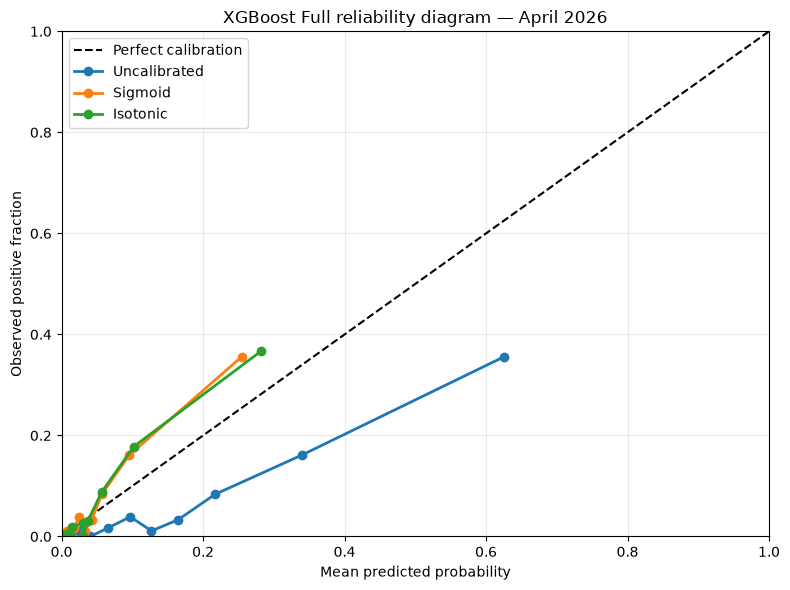

In [33]:
calibration_curve_points = {}

plt.figure(figsize=(8, 6))
plt.plot([0, 1], [0, 1], "k--", label="Perfect calibration")

for method, probability in calibration_candidates.items():
    fraction_positive, mean_predicted = calibration_curve(
        y_calibration_eval,
        probability,
        n_bins=10,
        strategy="quantile"
    )
    calibration_curve_points[method] = {
        "mean_predicted": mean_predicted,
        "fraction_positive": fraction_positive,
    }
    plt.plot(
        mean_predicted,
        fraction_positive,
        marker="o",
        linewidth=2,
        label=method
    )

plt.xlabel("Mean predicted probability")
plt.ylabel("Observed positive fraction")
plt.title("XGBoost Full reliability diagram — April 2026")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

### Calibration Selection

Sigmoid calibration is selected. On the April-only calibration evaluation period it obtains the lowest Brier score (**0.053826**), improving materially on the uncalibrated score (**0.068480**) and slightly on isotonic calibration (**0.054177**). Its PR-AUC (**0.415967**) and ROC-AUC (**0.864512**) are identical to the uncalibrated ranking because sigmoid is a monotonic transformation.

Isotonic calibration is competitive but does not improve Brier score over sigmoid. Its stepwise mapping also introduces tied probabilities, producing a slightly lower PR-AUC (**0.406908**) despite a marginally higher ROC-AUC (**0.866457**). The reliability diagram shows that both methods correct the marked overestimation of the original score; sigmoid is preferred for its marginally better Brier score and smoother, more robust mapping.

This decision uses no observation from May-August 2026. It selects only the probability transformation; it neither selects nor changes an operational alert threshold.

In [34]:
# Selected pre-holdout probability transformation. No alert threshold is set here.
selected_calibration_method = "Sigmoid"
selected_calibrator = sigmoid_calibrator

def apply_selected_calibrator(raw_score):
    raw_score = np.asarray(raw_score, dtype=float)
    return selected_calibrator.predict_proba(
        _score_to_logit(raw_score)
    )[:, 1]

# Explicit inference contract for the April calibration-evaluation sample:
# raw_score -> selected_calibrator -> calibrated_probability
raw_score = raw_score_eval
calibrated_probability = apply_selected_calibrator(raw_score)

assert np.all((calibrated_probability >= 0) & (calibrated_probability <= 1))
assert np.allclose(calibrated_probability, sigmoid_probability_eval)

print("Selected calibrator:", selected_calibration_method)
print("Inference contract: raw_score -> selected_calibrator -> calibrated_probability")
print("Operational alert threshold: not selected in this section")

Selected calibrator: Sigmoid
Inference contract: raw_score -> selected_calibrator -> calibrated_probability
Operational alert threshold: not selected in this section


## Industrial Threshold Selection

The classification threshold is now selected on `calibrated_probability`, not on the original XGBoost score and not by maximising F1 alone. The decision combines a minimum Recall requirement, review capacity, and the relative cost of False Negatives and False Positives.

The policy values are externalised in `configs/thresholds.yaml`. Because actual monetary costs and confirmed planner capacity are not yet available, the current values are explicitly **provisional engineering assumptions**: Recall at least 70%, no more than 15 alerts per active day on average, and a relative FN:FP cost ratio of 5:1. Operations must approve or replace them before production.

Threshold selection uses only the April 2026 calibration-evaluation sample. May-August 2026 remains excluded. The previous raw-score threshold of 0.425 is not numerically comparable with a calibrated-probability threshold.

In [35]:
from pathlib import Path
import yaml

def _find_repo_file(relative_path):
    current_path = Path.cwd().resolve()
    for repository_candidate in (current_path, *current_path.parents):
        candidate_path = repository_candidate / relative_path
        if candidate_path.exists():
            return candidate_path
    raise FileNotFoundError(f"Could not find repository file: {relative_path}")

threshold_config_path = _find_repo_file(Path("configs") / "thresholds.yaml")
with threshold_config_path.open("r", encoding="utf-8") as config_file:
    threshold_config = yaml.safe_load(config_file)

minimum_recall = float(
    threshold_config["operational_constraints"]["minimum_recall"]
)
maximum_average_alerts_per_active_day = float(
    threshold_config["operational_constraints"]
    ["maximum_average_alerts_per_active_day"]
)
false_negative_cost = float(
    threshold_config["relative_costs"]["false_negative"]
)
false_positive_cost = float(
    threshold_config["relative_costs"]["false_positive"]
)
threshold_grid_step = float(
    threshold_config["selection"]["threshold_grid_step"]
)

threshold_target = np.asarray(y_calibration_eval, dtype=int)
threshold_probability = np.asarray(calibrated_probability, dtype=float)
threshold_dates = pd.to_datetime(
    calibration_eval_df["Fecha"]
).reset_index(drop=True)

assert calibration_eval_df["Fecha"].max() < test_cutoff
assert threshold_config["score_field"] == "calibrated_probability"
assert threshold_config["calibration_method"].lower() == "sigmoid"
assert len(threshold_target) == len(threshold_probability) == len(threshold_dates)

active_days = int(threshold_dates.dt.normalize().nunique())
calendar_days = int((threshold_dates.max() - threshold_dates.min()).days + 1)
threshold_grid = np.round(
    np.arange(threshold_grid_step, 1.0, threshold_grid_step),
    6
)

threshold_records = []
for candidate_threshold in threshold_grid:
    candidate_alert = (
        threshold_probability >= candidate_threshold
    ).astype(int)
    tn, fp, fn, tp = confusion_matrix(
        threshold_target,
        candidate_alert,
        labels=[0, 1]
    ).ravel()
    n_alerts = int(candidate_alert.sum())
    threshold_records.append({
        "threshold": float(candidate_threshold),
        "precision": precision_score(
            threshold_target, candidate_alert, zero_division=0
        ),
        "recall": recall_score(
            threshold_target, candidate_alert, zero_division=0
        ),
        "f1": f1_score(
            threshold_target, candidate_alert, zero_division=0
        ),
        "alert_rate": float(candidate_alert.mean()),
        "n_alerts": n_alerts,
        "alerts_per_active_day": n_alerts / active_days,
        "alerts_per_calendar_day": n_alerts / calendar_days,
        "alerts_per_calendar_week": n_alerts / calendar_days * 7,
        "true_positives": int(tp),
        "false_positives": int(fp),
        "false_negatives": int(fn),
        "true_negatives": int(tn),
        "relative_cost": (
            false_negative_cost * fn
            + false_positive_cost * fp
        ),
    })

threshold_candidates = pd.DataFrame(threshold_records)
feasible_thresholds = threshold_candidates.loc[
    (threshold_candidates["recall"] >= minimum_recall)
    & (
        threshold_candidates["alerts_per_active_day"]
        <= maximum_average_alerts_per_active_day
    )
].copy()

if feasible_thresholds.empty:
    raise ValueError(
        "No calibrated threshold satisfies the configured Recall and "
        "review-capacity constraints."
    )

selected_threshold_row = (
    feasible_thresholds
    .sort_values(
        ["relative_cost", "n_alerts", "threshold"],
        ascending=[True, True, False]
    )
    .iloc[0]
)
selected_operational_threshold = float(
    selected_threshold_row["threshold"]
)

display(
    selected_threshold_row.to_frame("selected_candidate").round(6)
)

,selected_candidate
threshold,0.080000
precision,0.287540
recall,0.703125
f1,0.408163
alert_rate,0.173792
n_alerts,313.000000
alerts_per_active_day,14.904762
alerts_per_calendar_day,10.433333
alerts_per_calendar_week,73.033333
true_positives,90.000000


In [36]:
recall_frontier_records = []
for recall_target in [0.60, 0.65, 0.70, 0.75, 0.80, 0.85, 0.90]:
    recall_feasible = threshold_candidates.loc[
        threshold_candidates["recall"] >= recall_target
    ]
    frontier_row = (
        recall_feasible
        .sort_values(["n_alerts", "threshold"], ascending=[True, False])
        .iloc[0]
    )
    recall_frontier_records.append({
        "minimum_recall": recall_target,
        **frontier_row[[
            "threshold", "precision", "recall", "f1",
            "n_alerts", "alerts_per_active_day",
            "false_positives", "false_negatives"
        ]].to_dict(),
    })

recall_capacity_frontier = pd.DataFrame(recall_frontier_records)

cost_sensitivity_records = []
for fn_fp_ratio in [1, 2, 5, 10, 20, 50]:
    scenario = threshold_candidates.copy()
    scenario["scenario_cost"] = (
        fn_fp_ratio * scenario["false_negatives"]
        + scenario["false_positives"]
    )
    scenario_best = (
        scenario
        .sort_values(["scenario_cost", "n_alerts"])
        .iloc[0]
    )
    cost_sensitivity_records.append({
        "fn_fp_cost_ratio": fn_fp_ratio,
        **scenario_best[[
            "threshold", "precision", "recall",
            "n_alerts", "alerts_per_active_day",
            "false_positives", "false_negatives"
        ]].to_dict(),
        "relative_cost": scenario_best["scenario_cost"],
    })

threshold_cost_sensitivity = pd.DataFrame(cost_sensitivity_records)

print("Minimum alert load for each Recall requirement:")
display(recall_capacity_frontier.round(4))
print("Unconstrained cost optimum under alternative FN:FP ratios:")
display(threshold_cost_sensitivity.round(4))

Minimum alert load for each Recall requirement:


,minimum_recall,threshold,precision,recall,f1,n_alerts,alerts_per_active_day,false_positives,false_negatives
0,0.60,0.105,0.3277,0.6094,0.4262,238.0,11.3333,160.0,50.0
1,0.65,0.085,0.2872,0.6641,0.4009,296.0,14.0952,211.0,43.0
2,0.70,0.080,0.2875,0.7031,0.4082,313.0,14.9048,223.0,38.0
3,0.75,0.065,0.2553,0.7578,0.3819,380.0,18.0952,283.0,31.0
4,0.80,0.055,0.2244,0.8047,0.3509,459.0,21.8571,356.0,25.0
5,0.85,0.045,0.1869,0.8672,0.3075,594.0,28.2857,483.0,17.0
6,0.90,0.025,0.1188,0.9219,0.2105,993.0,47.2857,875.0,10.0


Unconstrained cost optimum under alternative FN:FP ratios:


,fn_fp_cost_ratio,threshold,precision,recall,n_alerts,alerts_per_active_day,false_positives,false_negatives,relative_cost
0,1,0.340,0.7778,0.2188,36.0,1.7143,8.0,100.0,108.0
1,2,0.330,0.7381,0.2422,42.0,2.0000,11.0,97.0,205.0
2,5,0.105,0.3277,0.6094,238.0,11.3333,160.0,50.0,410.0
3,10,0.065,0.2553,0.7578,380.0,18.0952,283.0,31.0,593.0
4,20,0.050,0.2093,0.8438,516.0,24.5714,408.0,20.0,808.0
5,50,0.020,0.1127,0.9688,1100.0,52.3810,976.0,4.0,1176.0


In [37]:
# Complete the inference contract on the April threshold-selection sample.
threshold = selected_operational_threshold
alert_flag = (calibrated_probability >= threshold).astype(int)

threshold_operational_df = calibration_eval_df[[
    "Fecha", "Grupo_raiz", target_col
]].copy()
threshold_operational_df["calibrated_probability"] = calibrated_probability
threshold_operational_df["alert_flag"] = alert_flag

threshold_daily_load = (
    threshold_operational_df
    .groupby("Fecha", as_index=False)
    .agg(
        observations=(target_col, "size"),
        missed_deliveries=(target_col, "sum"),
        alerts=("alert_flag", "sum")
    )
)
threshold_weekly_load = (
    threshold_operational_df
    .assign(week=lambda frame: frame["Fecha"].dt.to_period("W").astype(str))
    .groupby("week", as_index=False)
    .agg(
        observations=(target_col, "size"),
        missed_deliveries=(target_col, "sum"),
        alerts=("alert_flag", "sum")
    )
)
threshold_alerts_by_group = (
    threshold_operational_df.loc[threshold_operational_df["alert_flag"] == 1]
    .groupby("Grupo_raiz", as_index=False)
    .agg(
        alerts=("alert_flag", "sum"),
        missed_deliveries=(target_col, "sum"),
        mean_risk=("calibrated_probability", "mean")
    )
    .sort_values(["alerts", "mean_risk"], ascending=False)
)

configured_candidate = threshold_config["selected_candidate"]
assert np.isclose(threshold, configured_candidate["threshold"])
assert int(alert_flag.sum()) == int(configured_candidate["alerts"])
assert np.isclose(
    selected_threshold_row["recall"],
    configured_candidate["recall"]
)
assert threshold_config["governance"]["business_approved"] is False

print("Daily operational load:")
display(threshold_daily_load.describe().round(2))
print("Weekly operational load:")
display(threshold_weekly_load)
print("Planning groups with the most alerts (planner ownership not available):")
display(threshold_alerts_by_group.head(10).round(4))

Daily operational load:


,Fecha,observations,missed_deliveries,alerts
count,21,21.00,21.00,21.00
mean,2026-04-16 00:00:00,85.76,6.10,14.90
min,2026-04-01 00:00:00,2.00,2.00,1.00
25%,2026-04-08 00:00:00,82.00,3.00,6.00
50%,2026-04-16 00:00:00,99.00,5.00,12.00
75%,2026-04-23 00:00:00,108.00,8.00,21.00
max,2026-04-30 00:00:00,124.00,22.00,38.00
std,NaN,36.87,4.38,10.72


Weekly operational load:


,week,observations,missed_deliveries,alerts
0,2026-03-30/2026-04-05,110,13,24
1,2026-04-06/2026-04-12,312,19,39
2,2026-04-13/2026-04-19,515,44,85
3,2026-04-20/2026-04-26,492,29,80
4,2026-04-27/2026-05-03,372,23,85


Planning groups with the most alerts (planner ownership not available):


,Grupo_raiz,alerts,missed_deliveries,mean_risk
65,B969M0010,11,3,0.1422
53,A464MI01A,10,0,0.1066
21,7922S,9,3,0.1769
41,8605T0040,9,6,0.1059
38,8480I002Q,8,5,0.3328
71,C004M0010,8,0,0.2386
17,7054O0010,8,4,0.1367
72,C048M0010,8,1,0.1210
30,8257O00AQ,7,4,0.3097
31,8258OA0AQ,7,3,0.2885


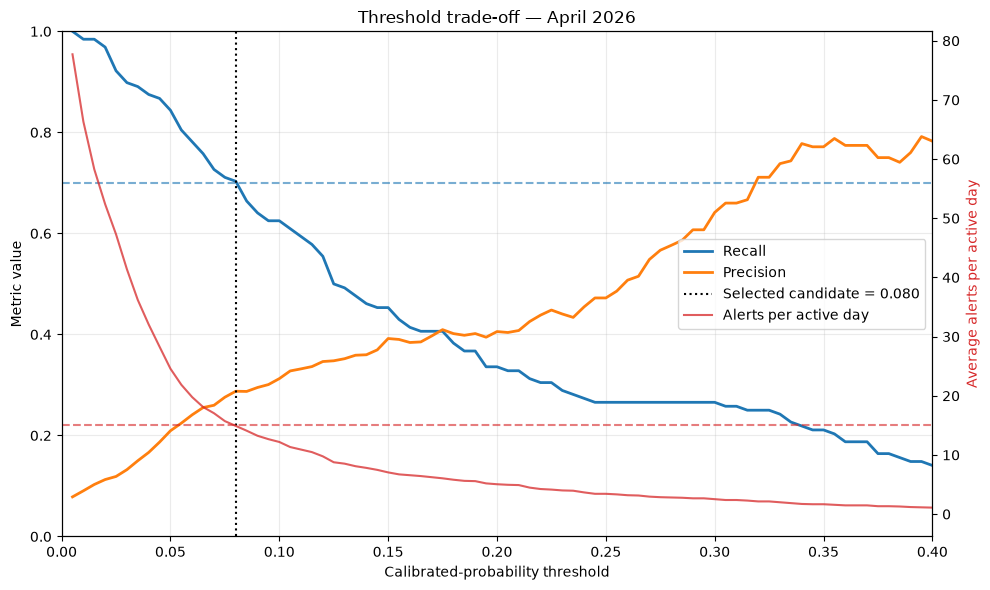

In [38]:
plot_thresholds = threshold_candidates.loc[
    threshold_candidates["n_alerts"] > 0
]

fig, metric_axis = plt.subplots(figsize=(10, 6))
load_axis = metric_axis.twinx()

metric_axis.plot(
    plot_thresholds["threshold"],
    plot_thresholds["recall"],
    label="Recall",
    linewidth=2
)
metric_axis.plot(
    plot_thresholds["threshold"],
    plot_thresholds["precision"],
    label="Precision",
    linewidth=2
)
load_axis.plot(
    plot_thresholds["threshold"],
    plot_thresholds["alerts_per_active_day"],
    color="tab:red",
    alpha=0.75,
    label="Alerts per active day"
)

metric_axis.axhline(
    minimum_recall, color="tab:blue", linestyle="--", alpha=0.6
)
load_axis.axhline(
    maximum_average_alerts_per_active_day,
    color="tab:red", linestyle="--", alpha=0.6
)
metric_axis.axvline(
    threshold, color="black", linestyle=":",
    label=f"Selected candidate = {threshold:.3f}"
)

metric_axis.set_xlim(0, min(0.40, plot_thresholds["threshold"].max()))
metric_axis.set_ylim(0, 1)
metric_axis.set_xlabel("Calibrated-probability threshold")
metric_axis.set_ylabel("Metric value")
load_axis.set_ylabel("Average alerts per active day", color="tab:red")
metric_axis.set_title("Threshold trade-off — April 2026")

metric_lines, metric_labels = metric_axis.get_legend_handles_labels()
load_lines, load_labels = load_axis.get_legend_handles_labels()
metric_axis.legend(
    metric_lines + load_lines, metric_labels + load_labels, loc="center right"
)
metric_axis.grid(alpha=0.25)
fig.tight_layout()
plt.show()

### Provisional Operational Decision

Under the configured policy, the selected technical candidate is **`calibrated_probability >= 0.080`**. On April 2026 it detects 90 of 128 Missed Deliveries: Recall **70.31%**, Precision **28.75%**, and F1-score **0.4082**. It generates 313 alerts across 21 active days, equivalent to **14.90 alerts per active day on average** and an alert rate of **17.38%**. The confusion counts are 90 TP, 223 FP, 38 FN, and 1,450 TN.

With provisional relative costs `C_FN = 5` and `C_FP = 1`, this candidate has a relative cost of **413**, compared with **640** for the no-alert policy, a reduction of approximately **35.5%**. This is a scenario result, not a monetary saving. The sensitivity table shows that the cost-optimal threshold changes materially when the FN:FP ratio changes; therefore the business-cost ratio must be validated.

The 15-alert capacity is an average, not a guarantee for every individual day. Daily and weekly load tables must be reviewed with the operational team, and planner ownership is not yet present in the dataset. If the real team capacity is materially below 15 alerts per active day, this model cannot simultaneously meet the provisional 70% Recall target without changing the operating process or improving the model.

The inference contract is now `raw_score -> selected_calibrator -> calibrated_probability -> threshold -> alert_flag`. The threshold remains marked `provisional_pending_business_approval`; it must not be treated as production-approved, and no May-August holdout observation was used to select it.

## Stability and Uncertainty

This section performs a final, deliberately compact stability audit of the already locked configuration: **XGBoost Full + sigmoid calibration + provisional threshold 0.08**. It does not fit a new model, recalibrate probabilities, change the threshold, compare candidates, or optimise hyperparameters.

April 2026 is shown as the threshold-selection month and must not be interpreted as independent evidence. May-August is used only for post-selection stability reporting. August ends on 25 August and is displayed separately as a partial month. No result in this section is used to reopen any modelling decision.

In [39]:
# Score later observations with the already fitted and locked pipeline.
stability_start = pd.Timestamp("2026-04-01")
stability_df = df.loc[df["Fecha"] >= stability_start].copy()

raw_score_stability = xgb_pipeline.predict_proba(
    stability_df[feature_cols]
)[:, 1]
calibrated_probability_stability = apply_selected_calibrator(
    raw_score_stability
)
stability_alert_flag = (
    calibrated_probability_stability >= threshold
).astype(int)

stability_df["raw_score"] = raw_score_stability
stability_df["calibrated_probability"] = (
    calibrated_probability_stability
)
stability_df["alert_flag"] = stability_alert_flag
stability_df["month"] = (
    stability_df["Fecha"].dt.to_period("M").astype(str)
)

assert selected_calibration_method == "Sigmoid"
assert np.isclose(threshold, 0.08)
assert stability_df["Fecha"].min() == pd.Timestamp("2026-04-01")
assert stability_df["Fecha"].max() == pd.Timestamp("2026-08-25")

stability_holdout_df = stability_df.loc[
    stability_df["Fecha"] >= test_cutoff
].copy().reset_index(drop=True)

print("Locked configuration: XGBoost Full + Sigmoid + threshold 0.08")
print("Stability reporting window:", stability_df["Fecha"].min(),
      "to", stability_df["Fecha"].max())
print("No fitting or configuration selection is performed in this section.")

Locked configuration: XGBoost Full + Sigmoid + threshold 0.08
Stability reporting window: 2026-04-01 00:00:00 to 2026-08-25 00:00:00
No fitting or configuration selection is performed in this section.


In [40]:
monthly_stability_records = []

for month, month_df in stability_df.groupby("month", sort=True):
    y_month = month_df[target_col].to_numpy()
    alert_month = month_df["alert_flag"].to_numpy()
    probability_month = month_df["calibrated_probability"].to_numpy()

    if month == "2026-04":
        period_role = "threshold selection"
    elif month == "2026-08":
        period_role = "partial holdout"
    else:
        period_role = "complete holdout"

    monthly_stability_records.append({
        "month": month,
        "period_role": period_role,
        "n_observations": len(month_df),
        "n_md": int(y_month.sum()),
        "precision": precision_score(
            y_month, alert_month, zero_division=0
        ),
        "recall": recall_score(
            y_month, alert_month, zero_division=0
        ),
        "f1": f1_score(y_month, alert_month, zero_division=0),
        "pr_auc": average_precision_score(
            y_month, probability_month
        ),
        "alert_rate": float(alert_month.mean()),
    })

monthly_stability = pd.DataFrame(monthly_stability_records)
display(monthly_stability.round(4))

,month,period_role,n_observations,n_md,precision,recall,f1,pr_auc,alert_rate
0,2026-04,threshold selection,1801,128,0.2875,0.7031,0.4082,0.4160,0.1738
1,2026-05,complete holdout,1832,128,0.2210,0.6406,0.3287,0.2753,0.2025
2,2026-06,complete holdout,1778,99,0.2365,0.7980,0.3649,0.3059,0.1879
3,2026-07,complete holdout,1792,88,0.1885,0.8182,0.3064,0.3221,0.2132
4,2026-08,partial holdout,295,45,0.5667,0.7556,0.6476,0.4537,0.2034


### Monthly Stability

Across the complete holdout months, Recall ranges from **64.06% in May** to **81.82% in July**. May is the weakest complete month in both Recall and PR-AUC (0.2753), while July has the lowest Precision (18.85%). June and July recover Recall without a major change in alert rate, which remains between approximately 18.8% and 21.3%. This indicates meaningful but not catastrophic temporal variation.

August shows stronger Precision and F1, but it contains only 295 observations and ends on 25 August. Its 45 positive cases are sufficient to report descriptively, but the month is incomplete and must not be compared directly with complete months or used to claim an improvement. April is likewise not independent evidence because its observations were used to select the provisional threshold. All monthly results remain descriptive: each month contains only 45 to 128 positive cases, so small differences must not be overinterpreted.

In [41]:
# Simple cluster bootstrap by target date on the May-August holdout.
# Resampling complete dates preserves within-day dependence.
bootstrap_iterations = 2000
bootstrap_rng = np.random.default_rng(42)
bootstrap_dates = stability_holdout_df["Fecha"].dt.normalize().to_numpy()
unique_bootstrap_dates = np.unique(bootstrap_dates)

bootstrap_target = stability_holdout_df[target_col].to_numpy()
bootstrap_alert = stability_holdout_df["alert_flag"].to_numpy()
bootstrap_probability = stability_holdout_df[
    "calibrated_probability"
].to_numpy()

bootstrap_records = []
for _ in range(bootstrap_iterations):
    sampled_dates = bootstrap_rng.choice(
        unique_bootstrap_dates,
        size=len(unique_bootstrap_dates),
        replace=True
    )
    sampled_index = np.concatenate([
        np.flatnonzero(bootstrap_dates == sampled_date)
        for sampled_date in sampled_dates
    ])

    y_bootstrap = bootstrap_target[sampled_index]
    alert_bootstrap = bootstrap_alert[sampled_index]
    probability_bootstrap = bootstrap_probability[sampled_index]

    if len(np.unique(y_bootstrap)) < 2 or alert_bootstrap.sum() == 0:
        continue

    bootstrap_records.append({
        "recall": recall_score(y_bootstrap, alert_bootstrap),
        "precision": precision_score(
            y_bootstrap, alert_bootstrap, zero_division=0
        ),
        "pr_auc": average_precision_score(
            y_bootstrap, probability_bootstrap
        ),
    })

bootstrap_samples = pd.DataFrame(bootstrap_records)
if len(bootstrap_samples) < bootstrap_iterations * 0.95:
    raise ValueError("Too many invalid bootstrap resamples")

holdout_target = stability_holdout_df[target_col].to_numpy()
holdout_alert = stability_holdout_df["alert_flag"].to_numpy()
holdout_probability = stability_holdout_df[
    "calibrated_probability"
].to_numpy()

stability_point_estimates = {
    "Recall": recall_score(holdout_target, holdout_alert),
    "Precision": precision_score(
        holdout_target, holdout_alert, zero_division=0
    ),
    "PR-AUC": average_precision_score(
        holdout_target, holdout_probability
    ),
}
bootstrap_column = {
    "Recall": "recall",
    "Precision": "precision",
    "PR-AUC": "pr_auc",
}

confidence_interval_records = []
for metric_name, estimate in stability_point_estimates.items():
    bootstrap_values = bootstrap_samples[bootstrap_column[metric_name]]
    confidence_interval_records.append({
        "metric": metric_name,
        "estimate": estimate,
        "ci_95_lower": bootstrap_values.quantile(0.025),
        "ci_95_upper": bootstrap_values.quantile(0.975),
        "bootstrap_unit": "target date",
        "valid_resamples": len(bootstrap_samples),
    })

stability_confidence_intervals = pd.DataFrame(
    confidence_interval_records
)
display(stability_confidence_intervals.round(4))

,metric,estimate,ci_95_lower,ci_95_upper,bootstrap_unit,valid_resamples
0,Recall,0.7417,0.6787,0.8078,target date,2000
1,Precision,0.2328,0.1971,0.2743,target date,2000
2,PR-AUC,0.2869,0.2408,0.3463,target date,2000


In [42]:
segment_variables = ["Grupo_raiz", "customer", "uat", "destination"]
minimum_segment_observations = 50
minimum_segment_positives = 5
minimum_segment_alerts = 5

segment_metric_records = []
for segment_variable in segment_variables:
    for segment_value, segment_df in stability_holdout_df.groupby(
        segment_variable, dropna=False
    ):
        y_segment = segment_df[target_col].to_numpy()
        alert_segment = segment_df["alert_flag"].to_numpy()
        true_positives_segment = int(
            ((y_segment == 1) & (alert_segment == 1)).sum()
        )
        segment_metric_records.append({
            "variable": segment_variable,
            "segment": str(segment_value),
            "n_observations": len(segment_df),
            "n_md": int(y_segment.sum()),
            "n_alerts": int(alert_segment.sum()),
            "true_positives": true_positives_segment,
            "false_negatives": int(y_segment.sum()) - true_positives_segment,
            "precision": precision_score(
                y_segment, alert_segment, zero_division=0
            ),
            "recall": recall_score(
                y_segment, alert_segment, zero_division=0
            ),
        })

segment_metrics = pd.DataFrame(segment_metric_records)
supported_segment_metrics = segment_metrics.loc[
    (segment_metrics["n_observations"] >= minimum_segment_observations)
    & (segment_metrics["n_md"] >= minimum_segment_positives)
    & (segment_metrics["n_alerts"] >= minimum_segment_alerts)
].copy()

segment_summary_records = []
for segment_variable in segment_variables:
    variable_metrics = supported_segment_metrics.loc[
        supported_segment_metrics["variable"] == segment_variable
    ]
    n_supported = len(variable_metrics)

    if n_supported == 0:
        recall_min = recall_max = precision_min = precision_max = np.nan
        comment = "No segments meet minimum support"
    else:
        recall_min = variable_metrics["recall"].min()
        recall_max = variable_metrics["recall"].max()
        precision_min = variable_metrics["precision"].min()
        precision_max = variable_metrics["precision"].max()
        if n_supported < 3:
            comment = "Too few supported segments for a stable range"
        elif (recall_max - recall_min >= 0.40) or (
            precision_max - precision_min >= 0.30
        ):
            comment = "High descriptive heterogeneity"
        else:
            comment = "Moderate descriptive heterogeneity"

    segment_summary_records.append({
        "variable": segment_variable,
        "supported_segments": n_supported,
        "recall_min": recall_min,
        "recall_max": recall_max,
        "precision_min": precision_min,
        "precision_max": precision_max,
        "comment": comment,
    })

segment_stability_summary = pd.DataFrame(segment_summary_records)
problem_segments_top5 = (
    supported_segment_metrics
    .sort_values(
        ["false_negatives", "recall", "n_md"],
        ascending=[False, True, False]
    )
    .head(5)
    [[
        "variable", "segment", "n_observations", "n_md",
        "n_alerts", "false_negatives", "recall", "precision"
    ]]
)

print(
    "Minimum support:", minimum_segment_observations, "observations,",
    minimum_segment_positives, "MD and", minimum_segment_alerts, "alerts"
)
display(segment_stability_summary.round(4))
print("Five supported segments with the most undetected MD:")
display(problem_segments_top5.round(4))

Minimum support: 50 observations, 5 MD and 5 alerts


,variable,supported_segments,recall_min,recall_max,precision_min,precision_max,comment
0,Grupo_raiz,1,0.4286,0.4286,0.1667,0.1667,Too few supported segments for a stable range
1,customer,9,0.0000,1.0000,0.0000,0.4552,High descriptive heterogeneity
2,uat,18,0.0000,0.9231,0.0000,0.5417,High descriptive heterogeneity
3,destination,9,0.0000,1.0000,0.0000,0.4552,High descriptive heterogeneity


Five supported segments with the most undetected MD:


,variable,segment,n_observations,n_md,n_alerts,false_negatives,recall,precision
272,uat,UATP11,202,27,28,12,0.5556,0.5357
233,customer,091A07,1465,11,18,11,0.0000,0.0000
314,destination,091A07D01,1465,11,18,11,0.0000,0.0000
258,customer,432005,162,72,134,11,0.8472,0.4552
345,destination,432005D01,162,72,134,11,0.8472,0.4552


### Stability Conclusion

1. **Temporal stability:** performance is reasonably stable for the current development stage, but it is not uniform. Across complete holdout months, Recall varies from 64.06% to 81.82%, Precision from 18.85% to 23.65%, and PR-AUC from 0.2753 to 0.3221.
2. **Weaker months:** May is the clearest weak month for Recall and PR-AUC; July has the lowest Precision. August appears stronger but is partial and cannot support a trend conclusion.
3. **Segment differences:** customer, UAT, and destination show high descriptive heterogeneity even after applying minimum support. Several supported flows have very low Recall. These results identify monitoring and data-improvement priorities, not causal effects and not evidence that another tested model would solve them. `Grupo_raiz` has too few sufficiently supported individual segments for a reliable range.
4. **Uncertainty:** on the May-August holdout, the date-cluster bootstrap gives 95% intervals of approximately **67.9%-80.8% for Recall**, **19.7%-27.4% for Precision**, and **0.241-0.346 for PR-AUC**. The intervals show meaningful uncertainty, especially for Precision and PR-AUC, but do not indicate unstable or degenerate performance.
5. **Freeze decision:** the weaker month and segment heterogeneity are limitations that must be monitored prospectively, but there is no serious evidence in this audit to reopen model selection, calibration, or threshold optimisation.

**XGBoost Full remains the selected final model configuration for the current development stage.**

Notebook 05 is scientifically closed after this section. Further evaluation of the locked configuration belongs in Notebook 06; production packaging, monitoring, and drift analysis belong in later engineering stages.

In [43]:
# ============================================================
# SAVE TOP-50 FEATURE CONFIGURATION
# ============================================================

top50_idx = np.sort(
    importance_order[:50]
)

top50_feature_names = [
    feature_names_transformed[i]
    for i in top50_idx
]

top50_importance_table = (
    xgb_importance
    .head(50)
    .copy()
)

print("Top-50 features retained:")
print(len(top50_feature_names))

display(
    top50_importance_table[
        ["feature", "importance"]
    ]
)

Top-50 features retained:
50


,feature,importance
0,destination_432008D01,0.028620
1,destination_091A07D01,0.023816
2,uat_UATZ2,0.023057
3,destination_097E30D01,0.021720
4,customer_073D61,0.015821
5,customer_091A07,0.014956
6,week_of_year,0.012730
7,customer_097E30,0.012060
8,uat_UATM19,0.011586
9,customer_432005,0.010456


## Final Locked Development Configuration

The coherent validation comparison identifies XGBoost Full as the primary model according to the pre-specified threshold-independent criterion, PR-AUC.

XGBoost Full uses all 467 transformed predictors and remains the selected final model configuration for the current development stage. XGBoost Top-50 remains only a compact secondary benchmark; the stability audit does not reopen that comparison.

The selected probability transformation is sigmoid calibration. The provisional operational rule is `calibrated_probability >= 0.08`; the earlier value 0.425 belongs to the uncalibrated validation score and is not the locked calibrated threshold. Business approval of the provisional cost and capacity assumptions remains pending.

Model selection, feature selection, calibration selection, and threshold selection use only information available before the May-August temporal holdout. The later monthly, bootstrap, and segment results are a post-selection stability audit: they document limitations but do not change any configuration. The earlier Logistic Regression baseline inspection remains an explicit limitation, and strictly blind evidence is deferred to prospective observations.

Notebook 05 is scientifically closed. The next step is to update Notebook 06 so that its final evaluation uses this locked XGBoost Full + sigmoid + 0.08 configuration, without retuning it on the holdout.

In [44]:
# ============================================================
# EXPORT TOP-50 FEATURE LIST
# ============================================================

top50_features_df = pd.DataFrame({
    "feature": top50_feature_names
})

top50_features_df.to_csv(
    "../../data/processed/top50_xgboost_features.csv",
    index=False
)

print(
    "Top-50 feature list exported successfully."
)

Top-50 feature list exported successfully.
